In [373]:
# Cells model for Senegal DHS 8 2018/2019 - data 1.9
# ----------------------------------------
# This file is used as a template base for the automated cell generator notebook.
# favicon in the cell above will be included in the broswer tab title.
# Version, author and date will be included as the first content.

# 🇸🇳 Senegal Segmentation Overview

<p>
Sonder Segmentation Science WS Team<br>
Data version: DHS 8 2018/2019 - data 1.9
</p>

In [374]:
# Load libraries
import re
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from plotly.subplots import make_subplots

# Configure Plotly renderer
# this enable chart in the exported HTML file
# https://github.com/microsoft/vscode-jupyter/issues/6999
pio.renderers.default = "notebook_connected"

In [375]:
# R Packages, libraries and utilities
import rpy2.robjects as ro
from rpy2.robjects import r, pandas2ri, default_converter
from rpy2.robjects.conversion import localconverter

In [376]:
# Check R version
r_version = ro.r('version')

In [377]:
pandas2ri.activate()
r('library(survey)')
r('library(base)')
r('library(dplyr)')

In [378]:
# load data
df = pd.read_csv("Senegal_2019_2018_DHS8_1.9-no-quotes.csv")

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_53214/1195113585.py:2: DtypeWarning:

Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.



In [379]:
# Renaming columns for better visualization
df.rename(columns={'segment_name': 'Segment'}, inplace=True)
df.rename(columns={'v012': 'Age'}, inplace=True)

# Column "v023" looks like "kaolack rurale" or "sedhiou urbain"
# Split the column 'v023' to get the state and the type (urban or rural)
df[['State', 'urban_rural']] = df['v023'].str.split(expand=True)

# Capitalize state
df['State'] = df['State'].str.capitalize()

# Translate values 'urbain' and 'rurale' to 'Urban' and 'Rural'
df['urban_rural'] = df['urban_rural'].str.lower().map({'urbain': 'Urban', 'rurale': 'Rural'})

In [380]:
# temporary fix for ranges interpreted as dates (e.g. "1-3" as "3-Jan")
def fix_excel_date_conversions(df, correction_maps):
    """
    Corrects values that Excel incorrectly converted using direct mappings

    Parameters:
    df: Pandas DataFrame
    correction_maps: Dictionary with columns as keys and substitution dictionaries as values

    Returns:
    Corrected DataFrame
    """
    
    df_corrected = df.copy()
    
    for column_name, substitutions in correction_maps.items():
        if column_name not in df_corrected.columns:
            print(f"Warning: Column '{column_name}' does not exist in the DataFrame")
            continue
            
        print(f"Processing column: {column_name}")
        
        # Display unique values before correction
        unique_before = df_corrected[column_name].value_counts()
        valores_a_corregir = [v for v in unique_before.index if str(v) in substitutions]
        
        if valores_a_corregir:
            print(f"  Values to fix: {valores_a_corregir}")
            
            # Apply substitutions using replace()
            df_corrected[column_name] = df_corrected[column_name].replace(substitutions)
            
            # Show corrections made
            for incorrect, correct in substitutions.items():
                count = (df_corrected[column_name] == correct).sum() - (df[column_name] == correct).sum()
                if count > 0:
                    print(f"    '{incorrect}' -> '{correct}' ({count} changes)")
        else:
            print(f"  No values were found to fix")
        
        print(f"  Unique values before: {sorted(df_corrected[column_name].dropna().unique())}")
        print("-" * 60)
    
    return df_corrected

In [381]:
# Define affected columns
affected_cols = ["num.preg.cat", "num.15up.cat", "num.under15.cat", "wd.index", "age.1stcohab.cat", "jd.index", "age.1stsex.cat"]

# Define correction dictionaries by column
correction_maps = {
    'num.preg.cat': {
        "3-Jan": "1-3",
        "6-Apr": "4-6"
        },
    'num.15up.cat': {
        "4-Mar": "3-4"
        },
    'num.under15.cat': {
        '2-Jan': '1-2', 
        '4-Mar': '3-4'
        },
    'wd.index': {
        '3-Jan': '1-3'
        },
    'age.1stcohab.cat': {
        '14-May': '5-14'
        },
    'jd.index': {
        '3-Jan': '1-3'
        },
    'age.1stsex.cat': {
        '14-May': '5-14'
        }
}

# Apply corrections
df = fix_excel_date_conversions(df, correction_maps)

Processing column: num.preg.cat
  No values were found to fix
  Unique values before: ['1-3', '4-6', '7+']
------------------------------------------------------------
Processing column: num.15up.cat
  No values were found to fix
  Unique values before: ['0-1', '2', '3-4', '5 and up']
------------------------------------------------------------
Processing column: num.under15.cat
  No values were found to fix
  Unique values before: ['0', '1-2', '3-4', '5 and up']
------------------------------------------------------------
Processing column: wd.index
  No values were found to fix
  Unique values before: ['0', '1-3', '4+', 'not partnered']
------------------------------------------------------------
Processing column: age.1stcohab.cat
  No values were found to fix
  Unique values before: ['15-19', '20+', '5-14']
------------------------------------------------------------
Processing column: jd.index
  No values were found to fix
  Unique values before: ['0', '1-3', '4+', 'not partnered'

In [382]:
# State names dictionary
state_corrections = {
    'Dakar': 'Dakar',
    'Diourbel': 'Diourbel',
    'Fatick': 'Fatick',
    'Kaffrine': 'Kaffrine',
    'Kaolack': 'Kaolack',
    'Kedougou': 'Kédougou',
    'Kolda': 'Kolda',
    'Louga': 'Louga',
    'Matam': 'Matam',
    'Saint-louis': 'Saint-Louis',
    'Sedhiou': 'Sédhiou',
    'Tambacounda': 'Tambacounda',
    'Thi<e8>s': 'Thiès',
    'Ziguinchor': 'Ziguinchor',
    'Ziquinchor': 'Ziguinchor'
}

# Replace values
df['State'] = df['State'].replace(state_corrections)

In [383]:
df_rural = df[df["urban_rural"] == "Rural"].copy()
df_urban = df[df["urban_rural"] == "Urban"].copy()

In [384]:
# Load your geojson data (replace with actual path)
geo_df = gpd.read_file('gadm41_SEN_1.json')

In [385]:
# Global variables required in the R runtime:
# ------------------------------------------

# Assign the R DataFrame to an R variable
ro.globalenv['senegal'] = df
ro.globalenv['urban'] = df_urban
ro.globalenv['rural'] = df_rural

# Define the survey design in R
# From Michael's design input (no strata used in complex survey design)

ro.r('urban.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=urban)')
ro.r('rural.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=rural)')
ro.r('senegal.des <-svydesign(id=~v021, strata=~v023, weights=~wt, data=senegal, nest=TRUE)')

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "part.workingnow.yn". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "yrs.curr.pship.cat". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjec

In [386]:
colors = {
    "Total": "#FFFFFF",  # White or transparent for root
    "Rural": "#7AC943",  # Blue for Rural category
    "Urban": "#7A8291",  # Green for Urban category
    # Rural segments
    "R2-S": "#14ABF7",
    "R3.1-S": "#B5A4EA",
    "R3.2-S": "#8B7FEA",
    "R4-S": "#F26185",
    # Urban segments
    "U1-S": "#21D6D6",
    "U2.1-S": "#14ABF7",
    "U2.2-S": "#0489CC",
    "U3.1-S": "#B5A4EA",
    "U3.2-S": "#8B7FEA"
}

colors_yes_no = {"Yes": "#88C1FD", "No": "#B3B3B3"}

In [387]:
def create_table(current_design: str,
                 var_of_interest: str,
                 labels: dict = {}) -> pd.DataFrame:
    """
    Create a contingency table with percentage and parcentege's SE 
    for each combination Segment - Category of var_of_interest
    """
    # 1) In R, calculate the table of frequencies
    r(f'''
      library(survey)
      current_table <- as.data.frame(
        svytable(~ Segment + {var_of_interest}, design = {current_design})
      )
      current_table$Segment <- as.character(current_table$Segment)
    ''')

    # 2) Take the data.frame from R and convert it to Pandas
    r_df = r('current_table')
    with localconverter(default_converter + pandas2ri.converter):
        df = pandas2ri.rpy2py(r_df)

    # 3) Calculate the percentage for each segment
    df['percentage'] = (
        df.groupby('Segment')['Freq']
          .transform(lambda x: x / x.sum() * 100)
          .round(2)
    )

    # 4) Apply labels (if any)
    if labels:
        inv = {v: k for k, v in labels.items()}
        df[var_of_interest] = (
            df[var_of_interest].astype(str)
                               .map(labels)
        )

    # 5) For each row, calculate the SE of the percentage, in R
    se_list = []
    for _, row in df.iterrows():
        seg = row['Segment']
        cat = row[var_of_interest]
        # take the original value of the category 
        cat_r = inv[cat] if labels else cat
        # in R, ratio (proportion) and SE with svymean of the indicator
        r_cmd = f'''
          prop <- svymean(
            ~I({var_of_interest}=="{cat_r}"),
            design = subset({current_design}, Segment=="{seg}"),
            na.rm=TRUE, se=TRUE
          )
          SE(prop)
        '''
        se_val = float(r(r_cmd)[0]) * 100
        se_list.append(round(se_val, 2))

    df['se_percentage'] = se_list

    return df

In [388]:
def create_bar_chart(current_data: pd.DataFrame,
                     var_of_interest: str,
                     title: str,
                     subtitle: str = None) -> px.bar:
    df = current_data.copy()
    # Prepare text and custom_data
    df["text_label"] = df["percentage"].round(1).astype(str) + "%"
    df["current_val"] = df[var_of_interest]
    custom = ["current_val", "percentage", "se_percentage"]
    
    # Procesar título y subtítulo con truncado
    if subtitle and subtitle.strip():
        # Truncar si es muy largo
        processed_subtitle = subtitle.strip()
        if len(processed_subtitle) > 100:
            processed_subtitle = processed_subtitle[:97] + "..."
        
        combined_title = f"{title}<br><span style='font-size: 14px; color: gray;'>{processed_subtitle}</span>"
    else:
        combined_title = title
    
    fig = px.bar(
        df,
        x='Segment',
        y='percentage',
        color=var_of_interest,
        text='text_label',
        custom_data=custom,
        labels={'percentage': 'Percentage', 'Segment': 'Segment'},
        title=combined_title,
        barmode='stack',
        color_discrete_sequence=[
            "#88C1FD", "#AF73C8", "#66C2A5", "#FB8686", "#FFD92F", 
            "#677BA1", "#B78C4E", "#E78AC3", "#A6D854", "#B3B3B3"
        ],
        color_discrete_map=colors_yes_no
    )
    
    # Hover template to show percentage and SE
    hover = (
        "<b>%{customdata[0]}</b><br>"
        "Segment: %{x}<br>"
        "Percentage: %{customdata[1]:.1f}%<br>"
        "SE: %{customdata[2]:.1f}%<extra></extra>"
    )
    
    fig.update_traces(
        textposition='auto',
        cliponaxis=False,
        textfont_size=16,
        hovertemplate=hover
    )
    
    # Layout con margen fijo para simplicidad
    fig.update_layout(
        title={
            'text': combined_title,
            'x': 0.5, 
            'xanchor': 'center',
            'font': dict(size=24, family="Arial", color="#333")
        },
        plot_bgcolor='#fcfcf7',
        margin=dict(t=120 if subtitle else 80),  # Margen fijo simple
        legend_title_text=var_of_interest
    )
    
    return fig

In [665]:
# Calculate stats for a numeric variable, by segment
# min, max, q1, q3, median
def create_stats(current_design, var_of_interest, exclude_outliers=False):
    r_code = """
    # Filter out segments with no valid data for this variable
    segments_with_data <- {cd}$variables %>%
        group_by(Segment) %>%
        summarise(valid_count = sum(!is.na({voi}) & is.finite(as.numeric({voi}))), .groups = 'drop') %>%
        filter(valid_count > 0) %>%
        pull(Segment)
    
    # Subset design to only segments with data
    filtered_design <- subset({cd}, Segment %in% segments_with_data)
    
    # Convert to numeric and filter out non-numeric values (strings)
    filtered_design$variables${voi} <- as.numeric(filtered_design$variables${voi})
    filtered_design <- subset(filtered_design, !is.na({voi}) & is.finite({voi}))
    
    {outlier_code}
    
    # Original calculations with filtered design
    median <- svyby(~{voi}, ~Segment, final_design, svyquantile, quantiles = c(0.5), na.rm = TRUE)
    median <- median %>% rename(median = {voi})
    q1 <- svyby(~{voi}, ~Segment, final_design, svyquantile, quantiles = c(0.25), na.rm = TRUE)
    q1 <- q1 %>% rename(q1 = {voi})
    q3 <- svyby(~{voi}, ~Segment, final_design, svyquantile, quantiles = c(0.75), na.rm = TRUE)
    q3 <- q3 %>% rename(q3 = {voi})
    min <- svyby(~{voi}, ~Segment, final_design, svyquantile, quantiles = c(0.0), na.rm = TRUE)
    min <- min %>% rename(min = {voi})
    max <- svyby(~{voi}, ~Segment, final_design, svyquantile, quantiles = c(1.0), na.rm = TRUE)
    max <- max %>% rename(max = {voi})
    stats <- full_join(q1, q3, by = "Segment")
    stats <- full_join(stats, median, by = "Segment")
    stats <- full_join(stats, min, by = "Segment")
    stats <- full_join(stats, max, by = "Segment")
    stats <- stats %>%
        select("Segment", "min", "q1", "median", "q3", "max")
    """.format(
        voi=var_of_interest, 
        cd=current_design,
        outlier_code="""
    # Exclude outliers if requested
    if ({exclude_outliers}) {{
        # Calculate overall IQR for outlier detection
        overall_q1 <- svyquantile(~{voi}, filtered_design, quantiles = c(0.25), na.rm = TRUE)
        overall_q3 <- svyquantile(~{voi}, filtered_design, quantiles = c(0.75), na.rm = TRUE)
        iqr <- overall_q3 - overall_q1
        lower_bound <- overall_q1 - 2 * iqr
        upper_bound <- overall_q3 + 2 * iqr
        
        # Filter out outliers
        final_design <- subset(filtered_design, {voi} >= lower_bound & {voi} <= upper_bound)
    }} else {{
        final_design <- filtered_design
    }}
        """.format(voi=var_of_interest, exclude_outliers=str(exclude_outliers).upper())
    )
    
    ro.r(r_code)
    table_stats = ro.r('stats')
    
    # conversion
    with (ro.default_converter + pandas2ri.converter).context():
        table_stats = ro.conversion.get_conversion().rpy2py(table_stats)
    
    return table_stats


In [390]:
def create_box_plot(current_data, var_of_interest, title):
    fig = go.Figure()
    
    for _, row in current_data.iterrows():
        fig.add_trace(go.Box(
            name=row['Segment'],
            x=[row['Segment']],
            q1=[row['q1']],
            median=[row['median']],
            q3=[row['q3']],
            lowerfence=[row['min']],
            upperfence=[row['max']],
            boxpoints=False,
            line=dict(color=colors.get(row['Segment'], 'blue')) if 'colors' in globals() else {}
        ))
    
    fig.update_layout(
        xaxis_title="Segment",
        yaxis_title=var_of_interest,
        title=title,
        title_x=0.5,
        showlegend=False
    )
    
    return fig

In [391]:
# table cell example, can be removed from template
# for the variable anc.less4 you use:
# -------------------------------------------------
# table_desc_fp = create_table("senegal.des", "desc.fp", {"respondent alone": "Respondent alone", "husband/ partner alone": "Husband / partner alone", "respondent and husband/ partner": "Respondent and husband / partner", "currently pregnant": "Currently pregnant", "other": "Other", "not partnered": "No partner"})

In [392]:
# chart cell example, can be removed from template
# for the variable anc.less4 you use:
# -------------------------------------------------
# create_bar_chart(table_desc_fp, "desc.fp", "Decision maker: family planning", "Who woman reported is Decision maker about family planning use or non-use").show()

In [393]:
# table cell example, can be removed from template
# for the variable partner.age (numeric) you use:
# -------------------------------------------------
# table_dv_index = create_stats("senegal.des", "dv.index")
# display(table_dv_index)

In [394]:
# Box plot cell example, can be removed from template
# for the variable partner.age (numeric) you use:
# -----------------------------------------------
# create_box_plot(table_dv_index, "dv.index", "Domestic violence experience")

## General Distribution

### Rural Segments

In [395]:
# RURAL Segments 
ro.r('table_dist_rural <- as.data.frame(svytable(~Segment, design = rural.des))')
ro.r('table_dist_rural$Segment <- as.character(table_dist_rural$Segment)')
table_dist_rural = ro.r('table_dist_rural')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_rural = ro.conversion.get_conversion().rpy2py(table_dist_rural)  

# calculate percentage
current_total = table_dist_rural['Freq'].sum()
table_dist_rural['percentage'] = table_dist_rural['Freq'] / current_total * 100

display(table_dist_rural.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage
1,R2-S,1970,35.8%
2,R3.1-S,501,9.1%
3,R3.2-S,1930,35.1%
4,R4-S,1099,20.0%


### Urban Segments

In [396]:
# URBAN Segments 
ro.r('table_dist_urban <- as.data.frame(svytable(~Segment, design = urban.des))')
ro.r('table_dist_urban$Segment <- as.character(table_dist_urban$Segment)')
table_dist_urban = ro.r('table_dist_urban')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_urban = ro.conversion.get_conversion().rpy2py(table_dist_urban)  

# calculate percentage
current_total = table_dist_urban['Freq'].sum()
table_dist_urban['percentage'] = table_dist_urban['Freq'] / current_total * 100

display(table_dist_urban.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage
1,U1-S,1064,31.3%
2,U2.1-S,1126,33.2%
3,U2.2-S,590,17.4%
4,U3.1-S,497,14.6%
5,U3.2-S,119,3.5%


### National Distribution

In [397]:
# All Senegal Segments 
ro.r('table_dist_senegal <- as.data.frame(svytable(~Segment, design = senegal.des))')
ro.r('table_dist_senegal$Segment <- as.character(table_dist_senegal$Segment)')
table_dist_senegal = ro.r('table_dist_senegal')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_senegal = ro.conversion.get_conversion().rpy2py(table_dist_senegal)  

# calculate percentage
current_total = table_dist_senegal['Freq'].sum()
table_dist_senegal['percentage'] = table_dist_senegal['Freq'] / current_total * 100
table_dist_senegal['Type'] = table_dist_senegal['Segment'].apply(lambda x: 'Rural' if x.startswith('R') else 'Urban')

display(table_dist_senegal.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage,Type
1,R2-S,1970,21.9%,Rural
2,R3.1-S,501,5.6%,Rural
3,R3.2-S,1930,21.5%,Rural
4,R4-S,1099,12.2%,Rural
5,U1-S,1075,12.0%,Urban
6,U2.1-S,1130,12.6%,Urban
7,U2.2-S,617,6.9%,Urban
8,U3.1-S,533,5.9%,Urban
9,U3.2-S,121,1.3%,Urban


In [398]:
# Prepare data for 2 level pie chart (sunburst)
def prepare_sunburst_data(df):
    # Create a copy to avoid modifying the original
    df_sunburst = df.copy()
    
    # Add a root node and type nodes
    root_and_types = pd.DataFrame({
        'Segment': ['Total', 'Rural', 'Urban'],
        'Type': ['', 'Total', 'Total'],  # Empty string for root, Total for Rural/Urban
        'percentage': [100, 
                      df[df['Type'] == 'Rural']['percentage'].sum(),
                      df[df['Type'] == 'Urban']['percentage'].sum()]
    })
    
    # Modify the Type column to point to Rural or Urban instead of Total
    df_sunburst['Type'] = df_sunburst['Type']
    
    # Combine the root and type rows with the data
    df_sunburst = pd.concat([root_and_types, df_sunburst], ignore_index=True)
    
    return df_sunburst

# Prepare the data
sunburst_data = prepare_sunburst_data(table_dist_senegal)

In [399]:
# Function to map colors based on the dictionary
def map_colors(df, color_dict):
    return [color_dict[segment] for segment in df['Segment']]

# Create a subplot with two charts (side by side)
fig = make_subplots(
    rows=1, cols=3,  # 1 row and 3 columns
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "sunburst"}]],  # Specify type of chart
    subplot_titles=("Rural Distribution", "Urban Distribution", "National Distribution")  # Titles for the subplots
)

# Add the pie chart for table_dist_rural
fig.add_trace(
    go.Pie(
        labels=table_dist_rural['Segment'],
        values=table_dist_rural['percentage'],
        marker=dict(colors=map_colors(table_dist_rural, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=1  # First row, first column
)

# Add the pie chart for table_dist_urban
fig.add_trace(
    go.Pie(
        labels=table_dist_urban['Segment'],
        values=table_dist_urban['percentage'],
        marker=dict(colors=map_colors(table_dist_urban, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=2  # First row, second column
)

# Modified sunburst trace
fig.add_trace(
    go.Sunburst(
        ids=sunburst_data['Segment'],
        labels=sunburst_data['Segment'],
        parents=sunburst_data['Type'],
        values=sunburst_data['percentage'],
        marker=dict(colors=map_colors(sunburst_data, colors)),
        branchvalues='total',
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=3
)

# Configure the layout and enforce the category order
fig.update_layout(
    title_text="Segment Distribution",  # Overall title
    title_x=0.5,  # Center the title
    annotations=[{"font": {"size": 14}}]  # Adjust the size of the subplot titles
)

# Show the chart
fig.show()


## Age Distribution

In [400]:
table_age_stats = create_stats("senegal.des", "Age")
display(table_age_stats.round(2))

,Segment,min,q1,median,q3,max
1,R2-S,15.0,25.0,31.0,38.0,49.0
2,R3.1-S,15.0,24.0,29.0,36.0,49.0
3,R3.2-S,15.0,25.0,31.0,38.0,49.0
4,R4-S,15.0,25.0,30.0,38.0,49.0
5,U1-S,15.0,28.0,35.0,40.0,49.0
6,U2.1-S,15.0,26.0,30.0,35.0,49.0
7,U2.2-S,15.0,30.0,36.0,44.0,49.0
8,U3.1-S,15.0,25.0,30.0,36.0,49.0
9,U3.2-S,18.0,33.0,42.0,45.0,49.0


In [401]:
create_box_plot(table_age_stats, "Age", "Distribution by Age")

## Geographic Distribution

In [402]:
table_geo_dist_rural = create_table("rural.des", "State")

# calculate alternative percentage
inner_total = table_geo_dist_rural.groupby('State')['Freq'].transform('sum')
table_geo_dist_rural['percentage_state'] = table_geo_dist_rural['Freq'] / inner_total * 100

table_geo_dist_urban = create_table("urban.des", "State")

# calculate alternative percentage
inner_total = table_geo_dist_urban.groupby('State')['Freq'].transform('sum')
table_geo_dist_urban['percentage_state'] = table_geo_dist_urban['Freq'] / inner_total * 100

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_53214/1118792274.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_53214/1118792274.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [403]:
# Map with pie charts over each state
# -----------------------------------

# Create the subplots
fig = make_subplots(
    rows=1, cols=2,  # 1 row and 2 columns
    subplot_titles=("Urban Distribution by State", "Rural Distribution by State")  # Titles for the plots
)

# Create a set to track segments already added to the legend
legend_segments = set()

# Urban chart (left side)
for segment in table_geo_dist_urban['Segment'].unique():
    segment_data = table_geo_dist_urban[table_geo_dist_urban['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Percentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=1  # Left chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Rural chart (right side)
for segment in table_geo_dist_rural['Segment'].unique():
    segment_data = table_geo_dist_rural[table_geo_dist_rural['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Percentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=2  # Right chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Configure the layout
fig.update_layout(
    title="Segment Distribution by State (Urban vs Rural)",
    barmode='stack',  # Stack the bars
    title_x=0.5,  # Center the title
    xaxis_title="State",
    yaxis_title="Percentage",
    legend_title="Segment",
)

# Display the charts
fig.show()


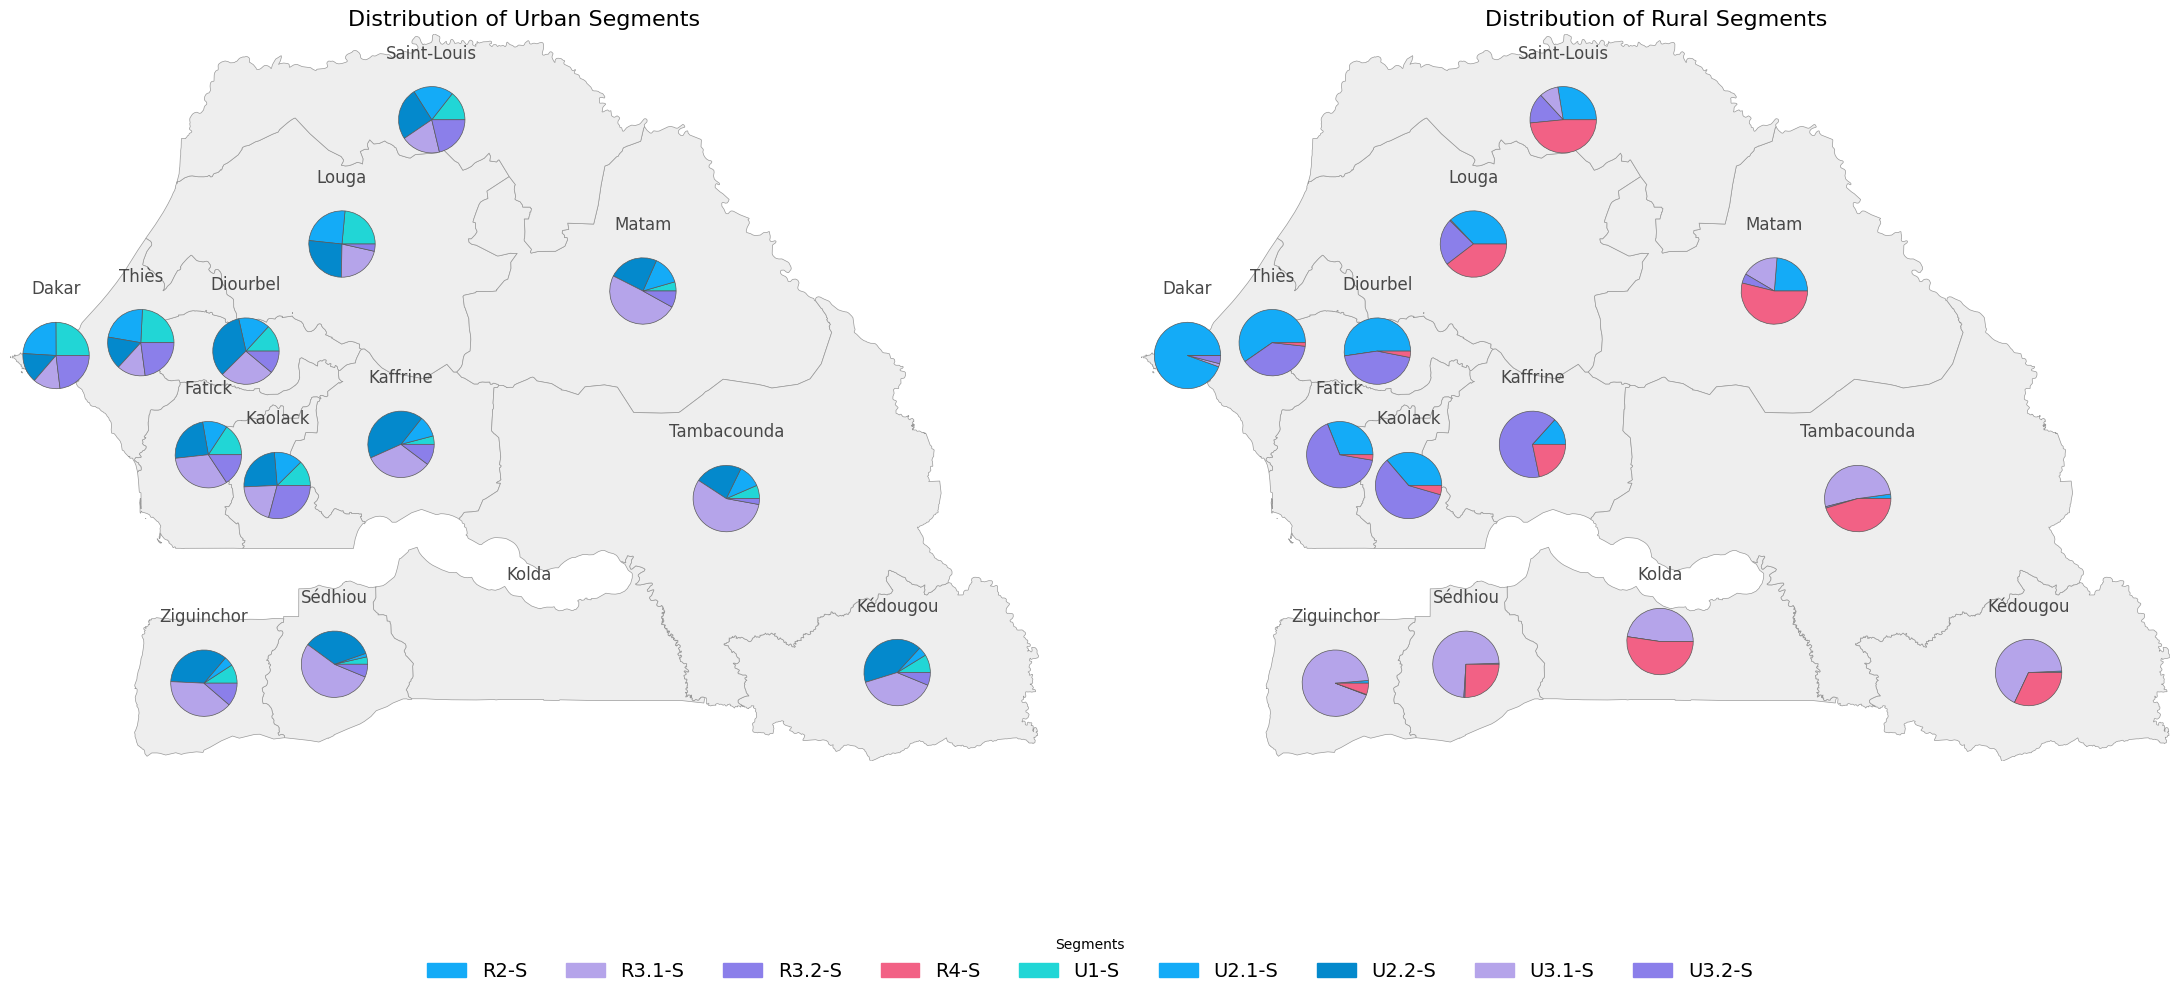

In [404]:
# Create the base map with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Two maps side by side

# Plot the base map
geo_df.plot(ax=axes[0], color='#EEE', edgecolor='#999', linewidth=0.5)
axes[0].set_title('Distribution of Urban Segments', fontsize=16)

def plot_pie_for_state(state, x, y, current_table, colors, ax):
    inner_current_table = current_table[current_table['State'] == state]
    
    # Ensure we plot only if there's valid data for this state
    if not inner_current_table.empty:
        sizes = inner_current_table['percentage']
        classes = inner_current_table['Segment']  # Get class names for each segment
        
         # Map each class to its corresponding color using the dictionary
        cls = [colors.get(cl, '#CCCCCC') for cl in classes]  # Default to gray if class not in dict
        ax.pie(sizes, center=(x, y), radius=0.2, colors=cls, wedgeprops=dict(edgecolor='#595959', linewidth=0.5))

# Plot pie charts for urban data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_urban, colors, axes[0])
    # Add state name as a label near the centroid
    axes[0].text(centroid.x, centroid.y + 0.4, state, fontsize=12, ha='center', va='center', color='#484848')

# Plot the second map with rural data
geo_df.plot(ax=axes[1], color='#EEE', edgecolor='#999', linewidth=0.5)
axes[1].set_title('Distribution of Rural Segments', fontsize=16)

# Plot pie charts for rural data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_rural, colors, axes[1])
    # Add state name as a label near the centroid
    axes[1].text(centroid.x, centroid.y + 0.4, state, fontsize=12, ha='center', va='center', color='#484848')

# Add a legend for the pie chart colors excluding Total, Rural, and Urban
excluded_segments = {"Total", "Rural", "Urban"}
legend_handles = [
    mpatches.Patch(color=color, label=segment)
    for segment, color in sorted(colors.items()) if segment not in excluded_segments
]
fig.legend(handles=legend_handles, loc='lower center', ncol=9, fontsize=14, frameon=False, title="Segments")

# Set map limits and hide axes
for ax in axes:
    ax.set_xlim(geo_df.total_bounds[0], geo_df.total_bounds[2])
    ax.set_ylim(geo_df.total_bounds[1], geo_df.total_bounds[3])
    ax.axis('off')

# Adjust layout for a cleaner appearance
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1)  # Adjust spacing between subplots

# Show the maps
plt.show()

## 1. Outcomes

### 1.1. Child health

#### 1.1.1. No PNC for newborn
*Variable name:* `baby.nohlthck`


Woman did not receive a postnatal check for baby within two months of birth for her most recent birth


In [405]:
table_baby_nohlthck = create_table("senegal.des", "baby.nohlthck", labels={'0': 'No', '1': 'Yes'})

In [406]:
create_bar_chart(table_baby_nohlthck, "baby.nohlthck", "No PNC for newborn", "Woman did not receive a postnatal check for baby within two months of birth for her most recent birth").show()

#### 1.1.2. Latest birth delivered at home
*Variable name:* `hb.1`

In [407]:
table_hb_1 = create_table("senegal.des", "hb.1", labels={'0': 'No', '1': 'Yes'})

In [408]:
create_bar_chart(table_hb_1, "hb.1", "Latest birth delivered at home", "Woman's most recent birth was delivered at home").show()

### 1.2. Family planning

#### 1.2.1. No current modern FP use
*Variable name:* `nofp.mod.now`

In [409]:
table_nofp_mod_now = create_table("senegal.des", "nofp.mod.now", labels={'0': 'No', '1': 'Yes'})

In [410]:
create_bar_chart(table_nofp_mod_now, "nofp.mod.now", "No current modern FP use", "Woman is not currently using any modern method of contraception").show()

#### 1.2.2. No PNC for mother
*Variable name:* `wom.nohlthck`


Woman did not receive any postnatal care (PNC), either before discharge from facility or after discharge/delivery at home


In [411]:
table_wom_nohlthck = create_table("senegal.des", "wom.nohlthck", labels={'0': 'No', '1': 'Yes'})

In [412]:
create_bar_chart(table_wom_nohlthck, "wom.nohlthck", "No PNC for mother", "Woman did not receive any postnatal care (PNC), either before discharge from facility or after discharge/delivery at home").show()

### 1.3. Immunisation

#### 1.3.1. Not fully immunized with DPT
*Variable name:* `dpt.full.yn`

In [413]:
table_dpt_full_yn = create_table("senegal.des", "dpt.full.yn", labels={'0': 'No', '1': 'Yes'})

In [414]:
create_bar_chart(table_dpt_full_yn, "dpt.full.yn", "Not fully immunized with DPT", "Woman has a child who is not fully immunized with DPT (diphtheria, pertussis, and tetanus) vaccine").show()

#### 1.3.2. Not immunized with MMR
*Variable name:* `meas.full.yn`

In [415]:
table_meas_full_yn = create_table("senegal.des", "meas.full.yn", labels={'0': 'No', '1': 'Yes'})

In [416]:
create_bar_chart(table_meas_full_yn, "meas.full.yn", "Not immunized with MMR", "Woman has a child who is not fully immunized with MMR (measles, mumps, rubella) vaccine").show()

#### 1.3.3. Not immunized with polio
*Variable name:* `polio.full.yn`

In [417]:
table_polio_full_yn = create_table("senegal.des", "polio.full.yn", labels={'0': 'No', '1': 'Yes'})

In [418]:
create_bar_chart(table_polio_full_yn, "polio.full.yn", "Not immunized with polio", "Woman has a child who is not fully immunized with polio vaccine").show()

#### 1.3.4. Zero-dose child
*Variable name:* `zerodose.yn`

In [419]:
table_zerodose_yn = create_table("senegal.des", "zerodose.yn", labels={'0': 'No', '1': 'Yes'})

In [420]:
create_bar_chart(table_zerodose_yn, "zerodose.yn", "Zero-dose child", "Woman has a child who did not receive any dose of the DPT vaccine").show()

### 1.4. Maternal health

#### 1.4.1. Less than 4 ANC visits
*Variable name:* `anc.less4`

In [421]:
table_anc_less4 = create_table("senegal.des", "anc.less4", labels={'0': 'No', '1': 'Yes'})

In [422]:
create_bar_chart(table_anc_less4, "anc.less4", "Less than 4 ANC visits", "Woman received less than four antenatal care visits for her most recent birth").show()

### 1.5. Nutrition

#### 1.5.1. Never breastfed
*Variable name:* `no.breastfed`

In [423]:
table_no_breastfed = create_table("senegal.des", "no.breastfed", labels={'0': 'No', '1': 'Yes'})

In [424]:
create_bar_chart(table_no_breastfed, "no.breastfed", "Never breastfed", "Woman never breastfed most recent birth/youngest child").show()

#### 1.5.2. Overweight child
*Variable name:* `ovrwgt.yn`

In [425]:
table_ovrwgt_yn = create_table("senegal.des", "ovrwgt.yn", labels={'0': 'No', '1': 'Yes'})

In [426]:
create_bar_chart(table_ovrwgt_yn, "ovrwgt.yn", "Overweight child", "Woman has a child who is overweight (high weight for height)").show()

#### 1.5.3. Pregnancy ended in stillbirth
*Variable name:* `stl.yn`

In [427]:
table_stl_yn = create_table("senegal.des", "stl.yn", labels={'0': 'No', '1': 'Yes'})

In [428]:
create_bar_chart(table_stl_yn, "stl.yn", "Pregnancy ended in stillbirth", "Woman experienced a stillbirth in the last 5 years").show()

#### 1.5.4. Stunted child
*Variable name:* `stunt.cat2.yn`

In [429]:
table_stunt_cat2_yn = create_table("senegal.des", "stunt.cat2.yn", labels={'0': 'No', '1': 'Yes'})

In [430]:
create_bar_chart(table_stunt_cat2_yn, "stunt.cat2.yn", "Stunted child", "Woman has a child who is stunted (low height for age)").show()

#### 1.5.5. Death of a child before 1 yr
*Variable name:* `u1mort.yn`

In [431]:
table_u1mort_yn = create_table("senegal.des", "u1mort.yn", labels={'0': 'No', '1': 'Yes'})

In [432]:
create_bar_chart(table_u1mort_yn, "u1mort.yn", "Death of a child before 1 yr", "Woman lost a child before age 1").show()

#### 1.5.6. Death of a child before 5 yrs
*Variable name:* `u5mort.yn`

In [433]:
table_u5mort_yn = create_table("senegal.des", "u5mort.yn", labels={'0': 'No', '1': 'Yes'})

In [434]:
create_bar_chart(table_u5mort_yn, "u5mort.yn", "Death of a child before 5 yrs", "Woman lost a child before age 5").show()

#### 1.5.7. Underweight child
*Variable name:* `undwgt.yn`

In [435]:
table_undwgt_yn = create_table("senegal.des", "undwgt.yn", labels={'0': 'No', '1': 'Yes'})

In [436]:
create_bar_chart(table_undwgt_yn, "undwgt.yn", "Underweight child", "Woman has a child who is underweight").show()

#### 1.5.8. Wasted child
*Variable name:* `waste.cat2.yn`

In [437]:
table_waste_cat2_yn = create_table("senegal.des", "waste.cat2.yn", labels={'0': 'No', '1': 'Yes'})

In [438]:
create_bar_chart(table_waste_cat2_yn, "waste.cat2.yn", "Wasted child", "Woman has a child who is wasted (low weight for height)").show()

## 2. Vulnerabilities

### 2.1. Health mental model 

#### 2.1.1. Child given beans/peas/lentils
*Variable name:* `bf.beans`

In [439]:
table_bf_beans = create_table("senegal.des", "bf.beans", labels={'0': 'No', '1': 'Yes'})

In [440]:
create_bar_chart(table_bf_beans, "bf.beans", "Child given beans/peas/lentils", "Woman gave most recent birth/youngest child age 0-23 months beans, peas, or lentils the previous day").show()

#### 2.1.2. Child given fortified food
*Variable name:* `bf.fortified.food`

In [441]:
table_bf_fortified_food = create_table("senegal.des", "bf.fortified.food", labels={'0': 'No', '1': 'Yes'})

In [442]:
create_bar_chart(table_bf_fortified_food, "bf.fortified.food", "Child given fortified food", "Woman gave most recent birth/youngest child age 0-23 months fortified baby food the previous day").show()

#### 2.1.3. Child given meat
*Variable name:* `bf.meat`


Woman gave most recent birth/youngest child age 0-23 months meat (beef, pork, lamb, goat, etc.) the previous day


In [443]:
table_bf_meat = create_table("senegal.des", "bf.meat", labels={'0': 'No', '1': 'Yes'})

In [444]:
create_bar_chart(table_bf_meat, "bf.meat", "Child given meat", "Woman gave most recent birth/youngest child age 0-23 months meat (beef, pork, lamb, goat, etc.) the previous day").show()

#### 2.1.4. Child given solid/soft food
*Variable name:* `bf.other.solid`


Woman gave most recent birth/youngest child age 0-23 months solid, semi-solid, or soft food the previous day


In [445]:
table_bf_other_solid = create_table("senegal.des", "bf.other.solid", labels={'0': 'No', '1': 'Yes'})

In [446]:
create_bar_chart(table_bf_other_solid, "bf.other.solid", "Child given solid/soft food", "Woman gave most recent birth/youngest child age 0-23 months solid, semi-solid, or soft food the previous day").show()

#### 2.1.5. Child given sweet snacks
*Variable name:* `bf.sweet.snacks`

In [447]:
table_bf_sweet_snacks = create_table("senegal.des", "bf.sweet.snacks", labels={'0': 'No', '1': 'Yes'})

In [448]:
create_bar_chart(table_bf_sweet_snacks, "bf.sweet.snacks", "Child given sweet snacks", "Woman gave most recent birth/youngest child age 0-23 months sweet snacks the previous day").show()

#### 2.1.6. Knows how to register a birth
*Variable name:* `birth.knowreg`

In [449]:
table_birth_knowreg = create_table("senegal.des", "birth.knowreg", labels={'no child <5': 'No child under 5', 'yes': 'Yes', 'no': 'No'})

In [450]:
create_bar_chart(table_birth_knowreg, "birth.knowreg", "Knows how to register a birth", "Woman knows how to register at least one birth among all births under 5 years").show()

#### 2.1.7. Any birth registered/declared
*Variable name:* `birth.reg.yn`

In [451]:
table_birth_reg_yn = create_table("senegal.des", "birth.reg.yn", labels={'no child <5': 'No child under 5', '1': 'Yes', '0': 'No'})

In [452]:
create_bar_chart(table_birth_reg_yn, "birth.reg.yn", "Any birth registered/declared", "Woman has at least one birth registered or declared among all births under 5 years").show()

#### 2.1.8. Condom use during last sex
*Variable name:* `condom.last.sex`

In [453]:
table_condom_last_sex = create_table("senegal.des", "condom.last.sex", labels={'no': 'No', 'yes': 'Yes'})

In [454]:
create_bar_chart(table_condom_last_sex, "condom.last.sex", "Condom use during last sex", "Woman reports that condom was used during last sex with most recent partner").show()

#### 2.1.9. Child treated for diarrhea
*Variable name:* `diarrhea.medtreat`

In [455]:
table_diarrhea_medtreat = create_table("senegal.des", "diarrhea.medtreat", labels={'yes, child was treated': 'Yes, child was treated', "no, child wasn't treated": 'No, child was not treated', "child didn't have diarrhea": 'Child did not have diarrhea'})

In [456]:
create_bar_chart(table_diarrhea_medtreat, "diarrhea.medtreat", "Child treated for diarrhea", "Woman has child who had diarrhea in last two weeks and received treatment").show()

#### 2.1.10. Provider for woman's PNC
*Variable name:* `discharge.checkedhealth`

In [457]:
table_discharge_checkedhealth = create_table("senegal.des", "discharge.checkedhealth", labels={'no one': 'No one', 'midwife/aux midwife': 'Midwife / Aux midwife', 'doctor/nurse': 'Doctor / Nurse', 'other/TBA': 'Other / TBA'})

In [458]:
create_bar_chart(table_discharge_checkedhealth, "discharge.checkedhealth", "Provider for woman's PNC", "Who woman reported provided postnatal care (PNC) after discharge from facility or home delivery").show()

#### 2.1.11. Fertility preference
*Variable name:* `fertility.pref`

In [459]:
table_fertility_pref = create_table("senegal.des", "fertility.pref", labels={'have another': 'Have another child', 'no more': 'No more child/ren', 'sterilized/infecund': 'Woman or partner is sterilized/declared infecund', 'undecided': 'Undecided'})

In [460]:
create_bar_chart(table_fertility_pref, "fertility.pref", "Fertility preference", "Woman's fertility preference").show()

#### 2.1.12. Preferred next birth interval
*Variable name:* `fertility.pref.cat`

In [461]:
table_fertility_pref_cat = create_table("senegal.des", "fertility.pref.cat", labels={'<2 years': 'Less than two years (<2)', '2-4 years': 'Two to four years (2-4)', '5+ years': 'Five or more years (5+)', 'No more': 'No more children', "don't know": 'Do not know'})

In [462]:
create_bar_chart(table_fertility_pref_cat, "fertility.pref.cat", "Preferred next birth interval", "Woman's preferred length of next birth interval").show()

#### 2.1.13. Partner opposition to FP use
*Variable name:* `fp.partner.oppose`


Woman is not using contraception despite wanting to limit or delay pregnancy for 2 years because partner opposes


In [463]:
table_fp_partner_oppose = create_table("senegal.des", "fp.partner.oppose", labels={'Partner opposes': 'Partner opposes', 'Partner does not oppose': 'Partner does not oppose', 'No identified need for FP': 'No identified need'})

In [464]:
create_bar_chart(table_fp_partner_oppose, "fp.partner.oppose", "Partner opposition to FP use", "Woman is not using contraception despite wanting to limit or delay pregnancy for 2 years because partner opposes").show()

#### 2.1.14. HH cooks food inside
*Variable name:* `hh.cook.inside.yn`

In [465]:
table_hh_cook_inside_yn = create_table("senegal.des", "hh.cook.inside.yn", labels={'0': 'No', '1': 'Yes'})

In [466]:
create_bar_chart(table_hh_cook_inside_yn, "hh.cook.inside.yn", "HH cooks food inside", "Woman's household cooks inside the house").show()

#### 2.1.15. HH water not treated
*Variable name:* `hh.nowatpur`

In [467]:
table_hh_nowatpur = create_table("senegal.des", "hh.nowatpur", labels={'0': 'No', '1': 'Yes'})

In [468]:
create_bar_chart(table_hh_nowatpur, "hh.nowatpur", "HH water not treated", "Woman's household does not do anything to make water safe to drink").show()

#### 2.1.16. HW visit in last yr
*Variable name:* `hw.visit.12mo`

In [469]:
table_hw_visit_12mo = create_table("senegal.des", "hw.visit.12mo", labels={'0': 'No', '1': 'Yes'})

In [470]:
create_bar_chart(table_hw_visit_12mo, "hw.visit.12mo", "HW visit in last yr", "Woman was visited by a health worker (agent de santé) in the last 12 months").show()

#### 2.1.17. HW talked about FP
*Variable name:* `hw.visit.fp`


Woman discussed family planning with a health worker (agent de santé) who visited in the last 12 months


In [471]:
table_hw_visit_fp = create_table("senegal.des", "hw.visit.fp", labels={'No HW visit': 'No health worker visit', 'HW discussed FP': 'Health worker discussed FP', 'HW did not discuss FP': 'Health worker did not discuss FP'})

In [472]:
create_bar_chart(table_hw_visit_fp, "hw.visit.fp", "HW talked about FP", "Woman discussed family planning with a health worker (agent de santé) who visited in the last 12 months").show()

#### 2.1.18. Heard of FGM
*Variable name:* `know.genitalcut`

In [473]:
table_know_genitalcut = create_table("senegal.des", "know.genitalcut", labels={'0': 'No', '1': 'Yes'})

In [474]:
create_bar_chart(table_know_genitalcut, "know.genitalcut", "Heard of FGM", "Woman has heard of female circumcision or female genital mutilation (FGM)").show()

#### 2.1.19. Partner FP information
*Variable name:* `m.fp.posters`


Woman's partner or husband has seen or read family planning information from posters or panels in the last few months


In [475]:
table_m_fp_posters = create_table("senegal.des", "m.fp.posters", labels={'no': 'No', 'yes': 'Yes'})

In [476]:
create_bar_chart(table_m_fp_posters, "m.fp.posters", "Partner FP information", "Woman's partner or husband has seen or read family planning information from posters or panels in the last few months").show()

#### 2.1.20. Access problem: travel alone
*Variable name:* `med.alone`


Woman reported not wanting to go alone is a big problem for wanting treatment or medical advice for herself when she is sick


In [477]:
table_med_alone = create_table("senegal.des", "med.alone", labels={'0': 'No', '1': 'Yes'})

In [478]:
create_bar_chart(table_med_alone, "med.alone", "Access problem: travel alone", "Woman reported not wanting to go alone is a big problem for wanting treatment or medical advice for herself when she is sick").show()

#### 2.1.21. Access problem: treatment cost
*Variable name:* `med.cost`


Woman reported cost for necessary treatment is a big problem when wanting treatment or medical advice for herself when she is sick


In [479]:
table_med_cost = create_table("senegal.des", "med.cost", labels={'0': 'No', '1': 'Yes'})

In [480]:
create_bar_chart(table_med_cost, "med.cost", "Access problem: treatment cost", "Woman reported cost for necessary treatment is a big problem when wanting treatment or medical advice for herself when she is sick").show()

#### 2.1.22. Access problem: distance to HF
*Variable name:* `med.dist`


Woman reported that distance to health facility is a big problem when wanting treatment or medical advice for herself when she is sick


In [481]:
table_med_dist = create_table("senegal.des", "med.dist", labels={'0': 'No', '1': 'Yes'})

In [482]:
create_bar_chart(table_med_dist, "med.dist", "Access problem: distance to HF", "Woman reported that distance to health facility is a big problem when wanting treatment or medical advice for herself when she is sick").show()

#### 2.1.23. Access problem: permission
*Variable name:* `med.permis`


Woman reported that getting permission to go to a doctor is a big problem when wanting treatment or medical advice for herself when she is sick


In [483]:
table_med_permis = create_table("senegal.des", "med.permis", labels={'0': 'No', '1': 'Yes'})

In [484]:
create_bar_chart(table_med_permis, "med.permis", "Access problem: permission", "Woman reported that getting permission to go to a doctor is a big problem when wanting treatment or medical advice for herself when she is sick").show()

#### 2.1.24. No. of pregnancies (2 category)
*Variable name:* `num.preg.moh.cat`

In [485]:
table_num_preg_moh_cat = create_table("senegal.des", "num.preg.moh.cat", labels={'1': 'One (1)', '2+': 'Two or more (2+)'})

In [486]:
create_bar_chart(table_num_preg_moh_cat, "num.preg.moh.cat", "No. of pregnancies (2 category)", "Number of pregnancies per woman").show()

#### 2.1.25. Partner's desire for children
*Variable name:* `partner.desire.child`

In [487]:
table_partner_desire_child = create_table("senegal.des", "partner.desire.child", labels={'both want same': 'Both want the same', 'husband wants more': 'Husband wants more', 'husband wants fewer': 'Husband wants fewer', "don't know": 'Do not know', 'not partnered': 'No partner'})

In [488]:
create_bar_chart(table_partner_desire_child, "partner.desire.child", "Partner's desire for children", "Woman's partner's or husband's desire for children").show()

#### 2.1.26. FP source: govt rural maternity
*Variable name:* `source.fp.gov`


Woman not currently using any contraceptive method reports government rural maternity as a source of family planning


In [489]:
table_source_fp_gov = create_table("senegal.des", "source.fp.gov", labels={'0': 'No', '1': 'Yes'})

In [490]:
create_bar_chart(table_source_fp_gov, "source.fp.gov", "FP source: govt rural maternity", "Woman not currently using any contraceptive method reports government rural maternity as a source of family planning").show()

#### 2.1.27. HH unimproved water source
*Variable name:* `water`

In [491]:
table_water = create_table("senegal.des", "water", labels={'0': 'No', '1': 'Yes'})

In [492]:
create_bar_chart(table_water, "water", "HH unimproved water source", "Woman's household does not use an improved drinking water source").show()

### 2.2. Household economics

#### 2.2.1. HH member w/ disability
*Variable name:* `disability.yn`

In [493]:
table_disability_yn = create_table("senegal.des", "disability.yn", labels={'0': 'No', '1': 'Yes'})

In [494]:
create_bar_chart(table_disability_yn, "disability.yn", "HH member w/ disability", "Woman's household includes member who has difficulty walking or climbing stairs").show()

#### 2.2.2. Earnings relative to partner
*Variable name:* `earnings.rel.partner`

In [495]:
table_earnings_rel_partner = create_table("senegal.des", "earnings.rel.partner", labels={'less than him': 'Less than him', 'about the same': 'About the same', 'more than him': 'More than him', "don't know": "Don't know", 'husband no earnings': 'Husband has no earnings'})

In [496]:
create_bar_chart(table_earnings_rel_partner, "earnings.rel.partner", "Earnings relative to partner", "Woman's earnings relative to partner or husband").show()

#### 2.2.3. Bank account (woman)
*Variable name:* `has.bank`

In [497]:
table_has_bank = create_table("senegal.des", "has.bank", labels={'no': 'No', 'yes': 'Yes'})

In [498]:
create_bar_chart(table_has_bank, "has.bank", "Bank account (woman)", "Woman has a bank account").show()

#### 2.2.4. Phone ownership (woman)
*Variable name:* `has.mobile`

In [499]:
table_has_mobile = create_table("senegal.des", "has.mobile", labels={'0': 'No', '1': 'Yes'})

In [500]:
create_bar_chart(table_has_mobile, "has.mobile", "Phone ownership (woman)", "Woman owns a mobile telephone").show()

#### 2.2.5. HH owns animals
*Variable name:* `hh.animal`

In [501]:
table_hh_animal = create_table("senegal.des", "hh.animal", labels={'0': 'No', '1': 'Yes'})

In [502]:
create_bar_chart(table_hh_animal, "hh.animal", "HH owns animals", "Woman's household owns livestock, herds or farm animals").show()

#### 2.2.6. HH received other state support
*Variable name:* `hh.autre`

In [503]:
table_hh_autre = create_table("senegal.des", "hh.autre", labels={'No support': 'No', 'Received support': 'Yes'})

In [504]:
create_bar_chart(table_hh_autre, "hh.autre", "HH received other state support", "Woman's household includes a member who received other forms of state support").show()

#### 2.2.7. Bank account (household)
*Variable name:* `hh.bank.acct`

In [505]:
table_hh_bank_acct = create_table("senegal.des", "hh.bank.acct", labels={'0': 'No', '1': 'Yes'})

In [506]:
create_bar_chart(table_hh_bank_acct, "hh.bank.acct", "Bank account (household)", "Woman's household includes a member who has a bank account").show()

#### 2.2.8. HH bicycle
*Variable name:* `hh.bike`

In [507]:
table_hh_bike = create_table("senegal.des", "hh.bike", labels={'0': 'No', '1': 'Yes'})

In [508]:
create_bar_chart(table_hh_bike, "hh.bike", "HH bicycle", "Woman's household owns bicycle").show()

#### 2.2.9. Family security grants
*Variable name:* `hh.bourse.moh.yn`


Woman's household includes member who received support from  Family Security Grants ("bourse de sécurité familiale)


In [509]:
table_hh_bourse_moh_yn = create_table("senegal.des", "hh.bourse.moh.yn", labels={'0': 'No', '1': 'Yes'})

In [510]:
create_bar_chart(table_hh_bourse_moh_yn, "hh.bourse.moh.yn", "Family security grants", "Woman's household includes member who received support from  Family Security Grants ('bourse de sécurité familiale')").show()

#### 2.2.10. HH car
*Variable name:* `hh.car`

In [511]:
table_hh_car = create_table("senegal.des", "hh.car", labels={'0': 'No', '1': 'Yes'})

In [512]:
create_bar_chart(table_hh_car, "hh.car", "HH car", "Woman's household owns a car or truck").show()

#### 2.2.11. HH animal-drawn cart
*Variable name:* `hh.cart`

In [513]:
table_hh_cart = create_table("senegal.des", "hh.cart", labels={'0': 'No', '1': 'Yes'})

In [514]:
create_bar_chart(table_hh_cart, "hh.cart", "HH animal-drawn cart", "Woman's household owns an animal-drawn cart").show()

#### 2.2.12. HH clean cooking fuel
*Variable name:* `hh.clean.fuel`

In [515]:
table_hh_clean_fuel = create_table("senegal.des", "hh.clean.fuel", labels={'0': 'No', '1': 'Yes'})

In [516]:
create_bar_chart(table_hh_clean_fuel, "hh.clean.fuel", "HH clean cooking fuel", "Woman's household uses clean fuels for cooking").show()

#### 2.2.13. HH computer
*Variable name:* `hh.computer`

In [517]:
table_hh_computer = create_table("senegal.des", "hh.computer", labels={'0': 'No', '1': 'Yes'})

In [518]:
create_bar_chart(table_hh_computer, "hh.computer", "HH computer", "Woman's household has a computer").show()

#### 2.2.14. HH electricity
*Variable name:* `hh.electricity`

In [519]:
table_hh_electricity = create_table("senegal.des", "hh.electricity", labels={'0': 'No', '1': 'Yes'})

In [520]:
create_bar_chart(table_hh_electricity, "hh.electricity", "HH electricity", "Woman's household has electricity").show()

#### 2.2.15. HH house ownership
*Variable name:* `hh.house.ownership`

In [521]:
table_hh_house_ownership = create_table("senegal.des", "hh.house.ownership", labels={'owner/ co-owner': 'Owner / Co-owner', 'renting/ co-renting/ tenant-buyer': 'Renting / Co-renting / Tenant-buyer', 'housed by employer/ family/ friend': 'Housed by employer / Family / Friend'})

In [522]:
create_bar_chart(table_hh_house_ownership, "hh.house.ownership", "HH house ownership", "Woman's household's house ownership status").show()

#### 2.2.16. HH internet
*Variable name:* `hh.internet`

In [523]:
table_hh_internet = create_table("senegal.des", "hh.internet", labels={'0': 'No', '1': 'Yes'})

In [524]:
create_bar_chart(table_hh_internet, "hh.internet", "HH internet", "Woman's household has internet").show()

#### 2.2.17. HH agricultural land ownership
*Variable name:* `hh.land`

In [525]:
table_hh_land = create_table("senegal.des", "hh.land", labels={'0': 'No', '1': 'Yes'})

In [526]:
create_bar_chart(table_hh_land, "hh.land", "HH agricultural land ownership", "Woman's household owns agricultural land").show()

#### 2.2.18. HH motorcycle or scooter
*Variable name:* `hh.motor`

In [527]:
table_hh_motor = create_table("senegal.des", "hh.motor", labels={'0': 'No', '1': 'Yes'})

In [528]:
create_bar_chart(table_hh_motor, "hh.motor", "HH motorcycle or scooter", "Woman's household owns a motorcycle or scooter").show()

#### 2.2.19. HH motor transport
*Variable name:* `hh.motortransport.yn`

In [529]:
table_hh_motortransport_yn = create_table("senegal.des", "hh.motortransport.yn", labels={'0': 'No', '1': 'Yes'})

In [530]:
create_bar_chart(table_hh_motortransport_yn, "hh.motortransport.yn", "HH motor transport", "Woman's household owns a motorcycle, car, or truck").show()

#### 2.2.20. HH rudimentary or natural floor
*Variable name:* `hh.noimp.floor`


Woman's household dwelling is made of natural or rudimentary floor material (e.g., earth, sand, dung, wood planks, palm or bamboo)


In [531]:
table_hh_noimp_floor = create_table("senegal.des", "hh.noimp.floor", labels={'0': 'No', '1': 'Yes'})

In [532]:
create_bar_chart(table_hh_noimp_floor, "hh.noimp.floor", "HH rudimentary or natural floor", "Woman's household dwelling is made of natural or rudimentary floor material (e.g., earth, sand, dung, wood planks, palm or bamboo)").show()

#### 2.2.21. No. of HHs sharing toilet
*Variable name:* `hh.num.sharelatrine`

In [533]:
stats_hh_num_sharelatrine = create_stats("senegal.des", "hh.num.sharelatrine")

In [534]:
create_box_plot(stats_hh_num_sharelatrine, "hh.num.sharelatrine", "No. of HHs sharing toilet").show()

#### 2.2.22. HH radio
*Variable name:* `hh.radio`

In [535]:
table_hh_radio = create_table("senegal.des", "hh.radio", labels={'0': 'No', '1': 'Yes'})

In [536]:
create_bar_chart(table_hh_radio, "hh.radio", "HH radio", "Woman's household has radio").show()

#### 2.2.23. HH member receives money
*Variable name:* `hh.recv.funds`

In [537]:
table_hh_recv_funds = create_table("senegal.des", "hh.recv.funds", labels={'Received from Senegal': 'Yes, received money from Senegal', 'Received from International': 'Yes, received money from abroad', "Did not receive/ Don't know": "No / Don't know"})

In [538]:
create_bar_chart(table_hh_recv_funds, "hh.recv.funds", "HH member receives money", "Woman's household includes a member who received money from within Senegal or abroad").show()

#### 2.2.24. HH received money
*Variable name:* `hh.recv.funds.cat`

In [539]:
table_hh_recv_funds_cat = create_table("senegal.des", "hh.recv.funds.cat", labels={'Received funds': 'Yes', "Did not receive/ Don't know": "No / Don't know"})

In [540]:
create_bar_chart(table_hh_recv_funds_cat, "hh.recv.funds.cat", "HH received money", "Woman's household includes member who received money from within Senegal or abroad").show()

#### 2.2.25. HH refrigerator
*Variable name:* `hh.refrig`

In [541]:
table_hh_refrig = create_table("senegal.des", "hh.refrig", labels={'0': 'No', '1': 'Yes'})

In [542]:
create_bar_chart(table_hh_refrig, "hh.refrig", "HH refrigerator", "Woman's household has a refrigerator").show()

#### 2.2.26. No. of rooms for sleeping
*Variable name:* `hh.rooms.num`

In [543]:
stats_hh_rooms_num = create_stats("senegal.des", "hh.rooms.num")

In [544]:
create_box_plot(stats_hh_rooms_num, "hh.rooms.num", "No. of rooms for sleeping").show()

#### 2.2.27. HH sanitation
*Variable name:* `hh.sanitation`

In [545]:
table_hh_sanitation = create_table("senegal.des", "hh.sanitation", labels={'No washing station': 'No washing station', 'Water and soap observed': 'Water and soap', 'Water but no soap observed': 'Water but no soap', 'No water or soap observed': 'No water and soap', 'Washing place not observed': 'Washing place not observed', 'Soap but no water observed': 'Soap but no water'})

In [546]:
create_bar_chart(table_hh_sanitation, "hh.sanitation", "HH sanitation", "Hand washing station at woman's household").show()

#### 2.2.28. HH sanitation (3 category)
*Variable name:* `hh.sanitation.cat`

In [547]:
table_hh_sanitation_cat = create_table("senegal.des", "hh.sanitation.cat", labels={'No washing station or place observed': 'No washing station / place', 'Water and soap observed': 'Water and soap', 'No water and/or soap observed': 'No water and / or soap'})

In [548]:
create_bar_chart(table_hh_sanitation_cat, "hh.sanitation.cat", "HH sanitation (3 category)", "Hand washing station at woman's household").show()

#### 2.2.29. HH member of savings club
*Variable name:* `hh.savingsclub`

In [549]:
table_hh_savingsclub = create_table("senegal.des", "hh.savingsclub", labels={'0': 'No', '1': 'Yes'})

In [550]:
create_bar_chart(table_hh_savingsclub, "hh.savingsclub", "HH member of savings club", "Woman's household includes a member of a savings club").show()

#### 2.2.30. HH member sends money
*Variable name:* `hh.send.funds`

In [551]:
table_hh_send_funds = create_table("senegal.des", "hh.send.funds", labels={"Do not send/ Don't know": "No / Don't know", 'Send to Senegal': 'Yes, sends to Senegal', 'Send International': 'Yes, sends abroad'})

In [552]:
create_bar_chart(table_hh_send_funds, "hh.send.funds", "HH member sends money", "Woman's household includes a member who sends money to Senegal or abroad").show()

#### 2.2.31. HH member sends money (binary)
*Variable name:* `hh.send.funds.cat`

In [553]:
table_hh_send_funds_cat = create_table("senegal.des", "hh.send.funds.cat", labels={'Send funds': 'Yes', "Do not send/ Don't know": "No / Don't know"})

In [554]:
create_bar_chart(table_hh_send_funds_cat, "hh.send.funds.cat", "HH member sends money (binary)", "Woman's household includes a member who sends money to Senegal or abroad").show()

#### 2.2.32. HH shares toilet
*Variable name:* `hh.shared.latrine`

In [555]:
table_hh_shared_latrine = create_table("senegal.des", "hh.shared.latrine", labels={'0': 'No', '1': 'Yes'})

In [556]:
create_bar_chart(table_hh_shared_latrine, "hh.shared.latrine", "HH shares toilet", "Woman's household shares toilet with other household/s").show()

#### 2.2.33. HH stove
*Variable name:* `hh.stove`

In [557]:
table_hh_stove = create_table("senegal.des", "hh.stove", labels={'0': 'No', '1': 'Yes'})

In [558]:
create_bar_chart(table_hh_stove, "hh.stove", "HH stove", "Woman's household owns a stove").show()

#### 2.2.34. HH televisition
*Variable name:* `hh.tv`

In [559]:
table_hh_tv = create_table("senegal.des", "hh.tv", labels={'0': 'No', '1': 'Yes'})

In [560]:
create_bar_chart(table_hh_tv, "hh.tv", "HH televisition", "Woman's household has television").show()

#### 2.2.35. HH VCR/DVD/CD player
*Variable name:* `hh.video`

In [561]:
table_hh_video = create_table("senegal.des", "hh.video", labels={'0': 'No', '1': 'Yes'})

In [562]:
create_bar_chart(table_hh_video, "hh.video", "HH VCR/DVD/CD player", "Woman's household has a VCR or CD/DVD player").show()

#### 2.2.36. Where HH cooks food (6 category)
*Variable name:* `hh.where.cook`

In [563]:
table_hh_where_cook = create_table("senegal.des", "hh.where.cook", labels={'Food cooked inside in a separate kitchen': 'Food cooked inside in a separate kitchen', 'Food cooked inside': 'Food cooked inside', 'Food cooked outdoors': 'Food cooked outdoors', 'Food cooked in a separate building': 'Food cooked in a separate building', 'No food cooked in house': 'No food cooked in the house', 'Other': 'Other'})

In [564]:
create_bar_chart(table_hh_where_cook, "hh.where.cook", "Where HH cooks food (6 category)", "Where woman's household cooks food").show()

#### 2.2.37. Home ownership
*Variable name:* `jnt.house.ownership`

In [565]:
table_jnt_house_ownership = create_table("senegal.des", "jnt.house.ownership", labels={'does not own': 'Does not own a house', 'alone only': 'Alone', 'jointly only': 'Jointly', 'both alone and jointly': 'Both alone and jointly'})

In [566]:
create_bar_chart(table_jnt_house_ownership, "jnt.house.ownership", "Home ownership", "Woman owns a house alone or jointly").show()

#### 2.2.38. Land ownership
*Variable name:* `jnt.land.ownership`

In [567]:
table_jnt_land_ownership = create_table("senegal.des", "jnt.land.ownership", labels={'does not own': 'Does not own land', 'alone only': 'Alone', 'jointly only': 'Jointly', 'both alone and jointly': 'Both alone and jointly'})

In [568]:
create_bar_chart(table_jnt_land_ownership, "jnt.land.ownership", "Land ownership", "Woman owns land alone or jointly").show()

#### 2.2.39. HH unimproved toilet
*Variable name:* `latrine`

In [569]:
table_latrine = create_table("senegal.des", "latrine", labels={'0': 'No', '1': 'Yes'})

In [570]:
create_bar_chart(table_latrine, "latrine", "HH unimproved toilet", "Woman's household uses unimproved toilet facility or open defecation").show()

#### 2.2.40. Child <2yr given solid/soft food
*Variable name:* `num.solidfood`


Woman has at least one child <2 years who ate solid, semi-solid or soft food at least once the day prior


In [571]:
table_num_solidfood = create_table("senegal.des", "num.solidfood", labels={'0': 'No', '1': 'Yes'})

In [572]:
create_bar_chart(table_num_solidfood, "num.solidfood", "Child <2yr given solid/soft food", "Woman has at least one child <2 years who ate solid, semi-solid or soft food at least once the day prior").show()

#### 2.2.41. Employer type
*Variable name:* `occ.type`

In [573]:
table_occ_type = create_table("senegal.des", "occ.type", labels={'Self': 'Self-employed', 'Family': 'Family', 'Someone else': 'Someone else', 'Did not work': 'Did not work'})

In [574]:
create_bar_chart(table_occ_type, "occ.type", "Employer type", "Who woman reported she works for (family, others, or self)").show()

#### 2.2.42. Occupation
*Variable name:* `occupation`

In [575]:
table_occupation = create_table("senegal.des", "occupation", labels={'not working': 'Not working', 'professional/technical/managerial': 'Professional, technical, managerial', 'clerical': 'Clerical', 'sales': 'Sales', 'agricultural - self employed': 'Agricultural (self-employed)', 'agricultural - employee': 'Agricultural (employee)', 'household and domestic': 'Household and domestic', 'services': 'Services', 'skilled manual': 'Skilled manual labor', 'unskilled manual': 'Unskilled manual labor', 'other': 'Other', "don't know": "Don't know"})

In [576]:
create_bar_chart(table_occupation, "occupation", "Occupation", "Woman's occupation").show()

#### 2.2.43. Occupation (7 category)
*Variable name:* `occupation.cat`

In [577]:
table_occupation_cat = create_table("senegal.des", "occupation.cat", labels={'professional/mangerial/ clerical': 'Professional, technical, managerial, or clerical', 'sales': 'Sales', 'agricultural': 'Agricultural (farming, livestock, fishing)', 'service/domestic': 'Household, domestic and services', 'manual': 'Skilled and unskilled manual labor', 'other': 'Other types of work', 'not working': 'Not working'})

In [578]:
create_bar_chart(table_occupation_cat, "occupation.cat", "Occupation (7 category)", "Woman's occupation").show()

#### 2.2.44. Employment status (partner)
*Variable name:* `part.working`

In [579]:
table_part_working = create_table("senegal.des", "part.working", labels={'Worked last 7 days': 'Worked last week', 'Worked last 12 months': 'Worked last year', "Didn't work last 12 months": 'Did not work last year', 'no partner': 'No partner'})

In [580]:
create_bar_chart(table_part_working, "part.working", "Employment status (partner)", "Woman's husband or partner's recent working status").show()

#### 2.2.45. Currently employed (partner)
*Variable name:* `part.workingnow.yn`

In [581]:
table_part_workingnow_yn = create_table("senegal.des", "part.workingnow.yn", labels={'Yes': 'Yes', 'no partner': 'No partner'})

In [582]:
create_bar_chart(table_part_workingnow_yn, "part.workingnow.yn", "Currently employed (partner)", "Woman's husband or partner is currently working").show()

#### 2.2.46. Occupation (partner)
*Variable name:* `partner.occupation`

In [583]:
table_partner_occupation = create_table("senegal.des", "partner.occupation", labels={'not working': 'Not working', 'professional/technical/managerial': 'Professional, technical, managerial', 'clerical': 'Clerical', 'sales': 'Sales', 'agricultural - self employed': 'Agricultural (self-employed)', 'agricultural - employee': 'Agricultural (employee)', 'household and domestic': 'Household and domestic', 'services': 'Services', 'skilled manual': 'Skilled manual labor', 'unskilled manual': 'Unskilled manual labor', 'other': 'Other', "don't know": "Don't know"})

In [584]:
create_bar_chart(table_partner_occupation, "partner.occupation", "Occupation (partner)", "Woman's husband or partner's occupation").show()

#### 2.2.47. Occupation (partner) (7 category)
*Variable name:* `partner.occupation.cat`

In [585]:
table_partner_occupation_cat = create_table("senegal.des", "partner.occupation.cat", labels={'professional/mangerial/ clerical': 'Professional, technical, managerial, or clerical', 'sales': 'Sales', 'agricultural': 'Agricultural (farming, livestock, fishing)', 'service/domestic': 'Household, domestic and services', 'manual': 'Skilled and unskilled manual labor', 'other/dk': "Other types of work / Don't know", 'not working': 'Not working'})

In [586]:
create_bar_chart(table_partner_occupation_cat, "partner.occupation.cat", "Occupation (partner) (7 category)", "Woman's husband or partner's occupation").show()

#### 2.2.48. Employment continuity
*Variable name:* `work.seasonal`

In [587]:
table_work_seasonal = create_table("senegal.des", "work.seasonal", labels={'All year': 'All year', 'Seasonal': 'Seasonal', 'Occassional': 'Occassional', 'No work in past 12 months': 'No work in the past 12 months'})

In [588]:
create_bar_chart(table_work_seasonal, "work.seasonal", "Employment continuity", "Woman's continuity of employment in the last year").show()

#### 2.2.49. Employment status
*Variable name:* `working`

In [589]:
table_working = create_table("senegal.des", "working", labels={'Currently working': 'Currently working', 'Worked in the past year': 'Worked in the past 12 months', 'On leave/absent': 'On leave / Absent', 'No work in the past 12 months': 'No work in the past 12 months'})

In [590]:
create_bar_chart(table_working, "working", "Employment status", "Woman's current employment status").show()

#### 2.2.50. Currently employed
*Variable name:* `workingnow.yn`

In [591]:
table_workingnow_yn = create_table("senegal.des", "workingnow.yn", labels={'0': 'No', '1': 'Yes'})

In [592]:
create_bar_chart(table_workingnow_yn, "workingnow.yn", "Currently employed", "Woman is currently employed").show()

### 2.3. Household relationship

#### 2.3.1. Decision maker: family planning
*Variable name:* `desc.fp`

In [593]:
table_desc_fp = create_table("senegal.des", "desc.fp", labels={'respondent alone': 'Respondent alone', 'husband/ partner alone': 'Husband / partner alone', 'respondent and husband/ partner': 'Respondent and husband / partner', 'currently pregnant': 'Currently pregnant', 'other': 'Other', 'not partnered': 'No partner'})

In [594]:
create_bar_chart(table_desc_fp, "desc.fp", "Decision maker: family planning", "Who woman reported makes decisions about family planning use or non-use").show()

#### 2.3.2. Decision maker: woman's health
*Variable name:* `desc.hlth`

In [595]:
table_desc_hlth = create_table("senegal.des", "desc.hlth", labels={'respondent alone': 'Respondent alone', 'husband/partner alone': 'Husband / partner alone', 'respondent and husband/partner': 'Respondent and husband / partner', 'someone else': 'Someone else', 'other': 'Other', 'not partnered': 'No partner'})

In [596]:
create_bar_chart(table_desc_hlth, "desc.hlth", "Decision maker: woman's health", "Who woman reported makes decisions about her health care").show()

#### 2.3.3. Decision maker: HH purchases
*Variable name:* `desc.lrgpur`

In [597]:
table_desc_lrgpur = create_table("senegal.des", "desc.lrgpur", labels={'respondent alone': 'Respondent alone', 'husband/partner alone': 'Husband / partner alone', 'respondent and husband/partner': 'Respondent and husband / partner', 'someone else': 'Someone else', 'other': 'Other', 'not partnered': 'No partner'})

In [598]:
create_bar_chart(table_desc_lrgpur, "desc.lrgpur", "Decision maker: HH purchases", "Who woman reported makes decisions about large household purchases").show()

#### 2.3.4. Decision maker: own income
*Variable name:* `desc.ownincome`

In [599]:
table_desc_ownincome = create_table("senegal.des", "desc.ownincome", labels={'respondent alone': 'Respondent alone', 'husband/partner alone': 'Husband / partner alone', 'respondent and husband/partner': 'Respondent and husband / partner', 'someone else': 'Someone else', 'Not paid in cash or not working': 'Not paid in cash or not working', 'not partnered': 'No partner'})

In [600]:
create_bar_chart(table_desc_ownincome, "desc.ownincome", "Decision maker: own income", "Who woman reported makes decisions about her own income").show()

#### 2.3.5. Decision maker: family visits
*Variable name:* `desc.visit`

In [601]:
table_desc_visit = create_table("senegal.des", "desc.visit", labels={'respondent alone': 'Respondent alone', 'husband/partner alone': 'Husband / partner alone', 'respondent and husband/partner': 'Respondent and husband / partner', 'someone else': 'Someone else', 'other': 'Not paid in cash or not working', 'not partnered': 'No partner'})

In [602]:
create_bar_chart(table_desc_visit, "desc.visit", "Decision maker: family visits", "Who woman reported makes decisions about visits to family or relatives").show()

#### 2.3.6. Polygamy status
*Variable name:* `first.wife`

In [603]:
table_first_wife = create_table("senegal.des", "first.wife", labels={'First wife': 'First wife', 'Second or more wife': 'Second wife or lower', 'Monomgaous union': 'Married with no other wife', 'not partnered': 'No partner'})

In [604]:
create_bar_chart(table_first_wife, "first.wife", "Polygamy status", "Woman's status in polygamous union").show()

#### 2.3.7. Sex of the head of HH
*Variable name:* `head.sex`

In [605]:
table_head_sex = create_table("senegal.des", "head.sex", labels={'male': 'Male', 'female': 'Female'})

In [606]:
create_bar_chart(table_head_sex, "head.sex", "Sex of the head of HH", "Sex of the head of woman's household").show()

#### 2.3.8. HH child to woman ratio
*Variable name:* `hh.kidwom.rat`

In [607]:
stats_hh_kidwom_rat = create_stats("senegal.des", "hh.kidwom.rat")

In [608]:
create_box_plot(stats_hh_kidwom_rat, "hh.kidwom.rat", "HH child to woman ratio").show()

#### 2.3.9. HH child to woman ratio (4 category)
*Variable name:* `hh.kidwom.rat.cat`

In [609]:
table_hh_kidwom_rat_cat = create_table("senegal.des", "hh.kidwom.rat.cat", labels={'0': 'zero', '1': 'between 0 and 1', '2': '1 up to 2', '3': '2 up to 3', '4': 'greater than 3'})

In [610]:
create_bar_chart(table_hh_kidwom_rat_cat, "hh.kidwom.rat.cat", "HH child to woman ratio (4 category)", "Ratio of children under 5 yrs old to women aged 15-49 yrs in woman's household").show()

#### 2.3.10. HH highest education: 7+
*Variable name:* `highestyearsedinHH.7plus`


Highest number of years of education attained by any member of woman's household is 7 years or higher


In [611]:
table_highestyearsedinHH_7plus = create_table("senegal.des", "highestyearsedinHH.7plus", labels={'0-7': 'Less than 7 years', '7+': '7 years or more'})

In [612]:
create_bar_chart(table_highestyearsedinHH_7plus, "highestyearsedinHH.7plus", "HH highest education: 7+", "Highest number of years of education attained by any member of woman's household is 7 years or higher").show()

#### 2.3.11. Joint decision making index
*Variable name:* `jd.index`

In [614]:
table_jd_index = create_table("senegal.des", "jd.index", labels={'0': '0', '1-3': '1-3', '4+': '4+', 'not partnered': 'No partner'})

In [615]:
create_bar_chart(table_jd_index, "jd.index", "Joint decision making index", "Woman's score on the joint decision-making index").show()

#### 2.3.12. Child <15yrs lives away
*Variable name:* `lives.away`

In [616]:
table_lives_away = create_table("senegal.des", "lives.away", labels={'0': 'No', '1': 'Yes'})

In [617]:
create_bar_chart(table_lives_away, "lives.away", "Child <15yrs lives away", "Woman's household includes a child under 15 living elsewhere").show()

#### 2.3.13. Age at first birth (partner)
*Variable name:* `m.age.1stbirth`

In [618]:
stats_m_age_1stbirth = create_stats("senegal.des", "m.age.1stbirth")

In [619]:
create_box_plot(stats_m_age_1stbirth, "m.age.1stbirth", "Age at first birth (partner)").show()

#### 2.3.14. Decides partner income (partner)
*Variable name:* `m.men.dec.earnings`

In [620]:
table_m_men_dec_earnings = create_table("senegal.des", "m.men.dec.earnings", labels={'0': 'No', '1': 'Yes'})

In [621]:
create_bar_chart(table_m_men_dec_earnings, "m.men.dec.earnings", "Decides partner income (partner)", "Woman's partner or husband reported that he alone decides how to spend his earnings").show()

#### 2.3.15. Decides HH purchases (partner)
*Variable name:* `m.men.dec.purchases`

In [622]:
table_m_men_dec_purchases = create_table("senegal.des", "m.men.dec.purchases", labels={'0': 'No', '1': 'Yes'})

In [623]:
create_bar_chart(table_m_men_dec_purchases, "m.men.dec.purchases", "Decides HH purchases (partner)", "Woman's partner or husband reported that he alone decides how to spend large household purchases").show()

#### 2.3.16. Partner no. of wives/partners
*Variable name:* `m.num.partners`

In [624]:
stats_m_num_partners = create_stats("senegal.des", "m.num.partners")

In [625]:
create_box_plot(stats_m_num_partners, "m.num.partners", "Partner no. of wives/partners").show()

#### 2.3.17. Married or living w/ partner
*Variable name:* `marr.cohab`

In [626]:
table_marr_cohab = create_table("senegal.des", "marr.cohab", labels={'0': 'No', '1': 'Yes'})

In [627]:
create_bar_chart(table_marr_cohab, "marr.cohab", "Married or living w/ partner", "Woman is currently married or living with partner").show()

#### 2.3.18. Child <3yr given micronutrient
*Variable name:* `micronutrient.12m`

In [628]:
table_micronutrient_12m = create_table("senegal.des", "micronutrient.12m", labels={'0': 'No', '1': 'Yes'})

In [629]:
create_bar_chart(table_micronutrient_12m, "micronutrient.12m", "Child <3yr given micronutrient", "Woman's household includes a child under 3 years given micronutrient powder in the last 12 months").show()

#### 2.3.19. No. over 15+ yrs
*Variable name:* `num.15up`

In [630]:
stats_num_15up = create_stats("senegal.des", "num.15up")

In [631]:
create_box_plot(stats_num_15up, "num.15up", "No. over 15+ yrs").show()

#### 2.3.20. No. over 15+ yrs (4 category)
*Variable name:* `num.15up.cat`

In [633]:
table_num_15up_cat = create_table("senegal.des", "num.15up.cat", labels={'0-1': 'None to one (0-1)', '2': 'Two (2)', '3-4': 'Three to four (3-4)', '5 and up': 'Five or more (5+)'})

In [634]:
create_bar_chart(table_num_15up_cat, "num.15up.cat", "No. over 15+ yrs (4 category)", "Number of members in woman's household aged 15 and above").show()

#### 2.3.21. No. <15 yrs
*Variable name:* `num.under15`

In [635]:
stats_num_under15 = create_stats("senegal.des", "num.under15")

In [636]:
create_box_plot(stats_num_under15, "num.under15", "No. <15 yrs").show()

#### 2.3.22. No. <15 yrs (4 category)
*Variable name:* `num.under15.cat`

In [639]:
table_num_under15_cat = create_table("senegal.des", "num.under15.cat", labels={'0': 'None (0)', '1-2': 'One to two (1-2)', '3-4': 'Three to four (3-4)', '5 and up': 'Five or more (5+)'})

In [640]:
create_bar_chart(table_num_under15_cat, "num.under15.cat", "No. <15 yrs (4 category)", "Number of members in woman's household below 15 years of age").show()

#### 2.3.23. No. <5 yrs
*Variable name:* `num.under5`

In [641]:
stats_num_under5 = create_stats("senegal.des", "num.under5")

In [642]:
create_box_plot(stats_num_under5, "num.under5", "No. <5 yrs").show()

#### 2.3.24. No. <5 yrs in HH (4 category)
*Variable name:* `num.under5.cat`

In [643]:
table_num_under5_cat = create_table("senegal.des", "num.under5.cat", labels={'0': 'None (0)', '1': 'One (1)', '2': 'Two (2)', '3+': 'Three or more (3+)'})

In [644]:
create_bar_chart(table_num_under5_cat, "num.under5.cat", "No. <5 yrs in HH (4 category)", "Number of members in the woman's household under the age of 5 years").show()

#### 2.3.25. Not living w/ partner
*Variable name:* `partner.absent.yn`

In [645]:
table_partner_absent_yn = create_table("senegal.des", "partner.absent.yn", labels={'0': 'No', '1': 'Yes'})

In [646]:
create_bar_chart(table_partner_absent_yn, "partner.absent.yn", "Not living w/ partner", "Woman is married or in union but does not live with partner").show()

#### 2.3.26. Partner age (4 category)
*Variable name:* `partner.age.cat`

In [647]:
table_partner_age_cat = create_table("senegal.des", "partner.age.cat", labels={'under 30': 'Under 30', '30-59': '30 - 59', '60+': '60+', 'not partnered': 'No partner'})

In [648]:
create_bar_chart(table_partner_age_cat, "partner.age.cat", "Partner age (4 category)", "Woman's partner's age (reported by woman)").show()

#### 2.3.27. At least primary education (partner) (4 category)
*Variable name:* `partner.anyed.yn`

In [649]:
table_partner_anyed_yn = create_table("senegal.des", "partner.anyed.yn", labels={'yes': 'Yes', 'no': 'No', "don't know": 'Do not know', 'not partnered': 'No partner'})

In [650]:
create_bar_chart(table_partner_anyed_yn, "partner.anyed.yn", "At least primary education (partner) (4 category)", "Woman's husband/partner attended at least primary education").show()

#### 2.3.28. Education level (partner)
*Variable name:* `partner.ed.level`

In [651]:
table_partner_ed_level = create_table("senegal.des", "partner.ed.level", labels={'no education': 'No education', 'primary': 'Primary', 'secondary': 'Secondary', 'higher': 'Higher', "don't know": 'Do not know', 'not partnered': 'No partner'})

In [652]:
create_bar_chart(table_partner_ed_level, "partner.ed.level", "Education level (partner)", "Woman's report of husband/partner's highest educational attainment").show()

#### 2.3.29. At least secondary education (partner)
*Variable name:* `partner.ed.level.moh.cat2`

In [653]:
table_partner_ed_level_moh_cat2 = create_table("senegal.des", "partner.ed.level.moh.cat2", labels={'some education': 'Primary or no education', 'higher education': 'Secondary or higher education'})

In [654]:
create_bar_chart(table_partner_ed_level_moh_cat2, "partner.ed.level.moh.cat2", "At least secondary education (partner)", "Woman's husband/partner attended at least secondary education").show()

#### 2.3.30. Polygamous relationship
*Variable name:* `polygamy`


Woman is currently in a polygamous relationship, defined as currently in union with a partner who has other wives or lives with other women as if married


In [655]:
table_polygamy = create_table("senegal.des", "polygamy", labels={'0': 'No', '1': 'Yes', 'not partnered': 'No partner'})

In [656]:
create_bar_chart(table_polygamy, "polygamy", "Polygamous relationship", "Woman is currently in a polygamous relationship, defined as currently in union with a partner who has other wives or lives with other women as if married").show()

#### 2.3.31. More than one union
*Variable name:* `prev.pship`

In [657]:
table_prev_pship = create_table("senegal.des", "prev.pship", labels={'No': 'No', 'Yes': 'Yes'})

In [658]:
create_bar_chart(table_prev_pship, "prev.pship", "More than one union", "Woman has had more than one union").show()

#### 2.3.32. Decision-making index
*Variable name:* `wd.index`

In [660]:
table_wd_index = create_table("senegal.des", "wd.index", labels={'0': '0', '1-3': '1-3', '4+': '4+', 'not partnered': 'No partner'})

In [661]:
create_bar_chart(table_wd_index, "wd.index", "Decision-making index", "Woman's decision making index score").show()

#### 2.3.33. Wife rank
*Variable name:* `wife.order`

In [662]:
table_wife_order = create_table("senegal.des", "wife.order", labels={'1': 'First (1)', '2': 'Second (2)', '3+': 'Third or higher (3+)', 'married with no other wives': 'Married with no other wife', 'not currently married': 'Not currently married'})

In [663]:
create_bar_chart(table_wife_order, "wife.order", "Wife rank", "Woman's rank among wives in polygamous union").show()

#### 2.3.34. Duration of current union
*Variable name:* `yrs.curr.pship`

In [666]:
stats_yrs_curr_pship = create_stats("senegal.des", "yrs.curr.pship")

R[write to console]: Además: 
R[write to console]: Avisos:

R[write to console]: 1: There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `valid_count = sum(!is.na(yrs.curr.pship) &
  is.finite(as.numeric(yrs.curr.pship)))`.
ℹ In group 1: `Segment = "R2-S"`.
Caused by warning:
! NAs introducidos por coerción
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings. 

R[write to console]: 2: 
R[write to console]: In (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  :
R[write to console]: 
 
R[write to console]:  NAs introducidos por coerción



In [668]:
create_box_plot(stats_yrs_curr_pship, "yrs.curr.pship", "Duration of current union").show()

### 2.4. Larger environment

#### 2.4.1. HH unimproved or shared facility
*Variable name:* `hh.noimp.latrine`


Woman's household uses unimproved (defined as pit latrine without slab or open pit, bucket, hanging toilet or hanging latrine, and no facilities or bush or field) or shared sanitation facilities


In [669]:
table_hh_noimp_latrine = create_table("senegal.des", "hh.noimp.latrine", labels={'0': 'No', '1': 'Yes'})

In [670]:
create_bar_chart(table_hh_noimp_latrine, "hh.noimp.latrine", "HH unimproved or shared facility", "Woman's household uses unimproved (defined as pit latrine without slab or open pit, bucket, hanging toilet or hanging latrine, and no facilities or bush or field) or shared sanitation facilities").show()

#### 2.4.2. HH <6 sleeping rooms
*Variable name:* `hh.rooms.num.moh.cat`

In [671]:
table_hh_rooms_num_moh_cat = create_table("senegal.des", "hh.rooms.num.moh.cat", labels={'<6': 'Less than 6 rooms', '6+': 'Six rooms or more'})

In [672]:
create_bar_chart(table_hh_rooms_num_moh_cat, "hh.rooms.num.moh.cat", "HH <6 sleeping rooms", "Woman's household has less than six rooms for sleeping, defined by Ministry of Health").show()

#### 2.4.3. HH slum residence (UN definition)
*Variable name:* `hh.urban.slum.un`


Woman resides in urban slum, meaning the household lacks one or more of the following conditions: access to improved water, access to improved sanitation, sufficient-living area, durability of housing, and security of tenure


In [673]:
table_hh_urban_slum_un = create_table("senegal.des", "hh.urban.slum.un", labels={'rural': 'Rural', 'urban slum': 'Urban slum', 'urban non-slum': 'Urban non-slum'})

In [674]:
create_bar_chart(table_hh_urban_slum_un, "hh.urban.slum.un", "HH slum residence (UN definition)", "Woman resides in urban slum, meaning the household lacks one or more of the following conditions: access to improved water, access to improved sanitation, sufficient-living area, durability of housing, and security of tenure").show()

#### 2.4.4. HH water source interrupted
*Variable name:* `hh.wat.interrupt`


Woman's household includes piped water source that did not have water for at least a day in the last two weeks


In [675]:
table_hh_wat_interrupt = create_table("senegal.des", "hh.wat.interrupt", labels={'Yes': 'Yes', 'No': 'No', 'Water not piped': 'Water not piped'})

In [676]:
create_bar_chart(table_hh_wat_interrupt, "hh.wat.interrupt", "HH water source interrupted", "Woman's household includes piped water source that did not have water for at least a day in the last two weeks").show()

#### 2.4.5. Where HH cooks food (3 category)
*Variable name:* `hh.where.cook.moh.cat`

In [677]:
table_hh_where_cook_moh_cat = create_table("senegal.des", "hh.where.cook.moh.cat", labels={'Food cooked inside': 'Food cooked inside', 'Food cooked outdoors': 'Food cooked outdoors', 'Other': 'Other'})

In [678]:
create_bar_chart(table_hh_where_cook_moh_cat, "hh.where.cook.moh.cat", "Where HH cooks food (3 category)", "Where woman's household cooks food").show()

#### 2.4.6. HH in malaria zone
*Variable name:* `malaria.zone`

In [679]:
table_malaria_zone = create_table("senegal.des", "malaria.zone", labels={'0-2.0': 'Zone 1: Dakar, St-Louis, Thiès, Louga, Matam', '2.1-6.0': 'Zone 2: Diourbel, Kaolack, Fatick, Kaffrine', '6.1-30': 'Zone 3: Ziguinchor, Tambacounda, Kolda, Kedougou, Sedhiou'})

In [680]:
create_bar_chart(table_malaria_zone, "malaria.zone", "HH in malaria zone", "Malaria risk classification based on geographic area for woman's household").show()

#### 2.4.7. Mobile phone used for finances
*Variable name:* `mobile.financial`

In [681]:
table_mobile_financial = create_table("senegal.des", "mobile.financial", labels={'no': 'No', 'yes': 'Yes'})

In [682]:
create_bar_chart(table_mobile_financial, "mobile.financial", "Mobile phone used for finances", "Woman has used a mobile phone to make financial transactions").show()

#### 2.4.8. HH no toilet facility
*Variable name:* `no.latrine`

In [683]:
table_no_latrine = create_table("senegal.des", "no.latrine", labels={'0': 'No', '1': 'Yes'})

In [684]:
create_bar_chart(table_no_latrine, "no.latrine", "HH no toilet facility", "Woman's household does not have a toilet facility or uses open defecation").show()

### 2.5. Social Support

#### 2.5.1. HH member w/o insurance
*Variable name:* `hh.no.insurance.yn`

In [685]:
table_hh_no_insurance_yn = create_table("senegal.des", "hh.no.insurance.yn", labels={'0': 'No', '1': 'Yes'})

In [686]:
create_bar_chart(table_hh_no_insurance_yn, "hh.no.insurance.yn", "HH member w/o insurance", "Woman's household includes at least one member without insurance").show()

### 2.6. Woman and her past experience

#### 2.6.1. Age at first birth
*Variable name:* `age.1stbrth`

In [687]:
stats_age_1stbrth = create_stats("senegal.des", "age.1stbrth")

In [688]:
create_box_plot(stats_age_1stbrth, "age.1stbrth", "Age at first birth").show()

#### 2.6.2. Age at first birth (3 category)
*Variable name:* `age.1stbrth.moh.cat1`

In [689]:
table_age_1stbrth_moh_cat1 = create_table("senegal.des", "age.1stbrth.moh.cat1", labels={'<20': 'Less than 20 years old', '20-29': '20 to 29 years old', '30+': '30 years old or more'})

In [690]:
create_bar_chart(table_age_1stbrth_moh_cat1, "age.1stbrth.moh.cat1", "Age at first birth (3 category)", "Woman's age at birth of first child").show()

#### 2.6.3. Age at first birth (5 category)
*Variable name:* `age.1stbrth.moh.cat2`

In [691]:
table_age_1stbrth_moh_cat2 = create_table("senegal.des", "age.1stbrth.moh.cat2", labels={'<15': 'Less than 15 years old', '15-19': '15 to 19 years old', '20-24': '20 to 24 years old', '25-39': '25 to 39 years old', '40+': '40 years old or more'})

In [692]:
create_bar_chart(table_age_1stbrth_moh_cat2, "age.1stbrth.moh.cat2", "Age at first birth (5 category)", "Woman's age at birth of first child").show()

#### 2.6.4. Age at first cohabitation
*Variable name:* `age.1stcohab`

In [693]:
stats_age_1stcohab = create_stats("senegal.des", "age.1stcohab")

R[write to console]: Además: 
R[write to console]: Avisos:

R[write to console]: 1: There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `valid_count = sum(!is.na(age.1stcohab) &
  is.finite(as.numeric(age.1stcohab)))`.
ℹ In group 5: `Segment = "U1-S"`.
Caused by warning:
! NAs introducidos por coerción
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning. 

R[write to console]: 2: 
R[write to console]: In (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  :
R[write to console]: 
 
R[write to console]:  NAs introducidos por coerción



In [694]:
create_box_plot(stats_age_1stcohab, "age.1stcohab", "Age at first cohabitation").show()

#### 2.6.5. Age at first cohabitation (3 category)
*Variable name:* `age.1stcohab.cat`

In [696]:
table_age_1stcohab_cat = create_table("senegal.des", "age.1stcohab.cat", labels={'5-14': 'Less than 15 years old', '15-19': '15 to 19 years old', '20+': '20 years old or more'})

In [697]:
create_bar_chart(table_age_1stcohab_cat, "age.1stcohab.cat", "Age at first cohabitation (3 category)", "Woman's age at first cohabitation with a partner").show()

#### 2.6.6. Age at first sex
*Variable name:* `age.1stsex`

In [698]:
stats_age_1stsex = create_stats("senegal.des", "age.1stsex")

In [699]:
create_box_plot(stats_age_1stsex, "age.1stsex", "Age at first sex").show()

#### 2.6.7. Age at first sex (4 category)
*Variable name:* `age.1stsex.cat`

In [701]:
table_age_1stsex_cat = create_table("senegal.des", "age.1stsex.cat", labels={'5-14': 'Less than 15 years old', '15-19': '15 to 19 years old', '20+': '20 years old or more', "Inconsistent or don't know": 'Inconsistent or do not know'})

In [702]:
create_bar_chart(table_age_1stsex_cat, "age.1stsex.cat", "Age at first sex (4 category)", "Woman's age at first sexual intercourse").show()

#### 2.6.8. Any media exposure
*Variable name:* `any.media.yn`


Woman accesses any form of media, based on responses to three questions: whether she listens to the radio, watches television, or reads a newspaper or magazine at least once a week, less than once a week, or not at all. The variable is coded as 1 if she reported any level of engagement (weekly or less than weekly) with at least one of these media types, and 0 if she reported no exposure to any of them.


In [703]:
table_any_media_yn = create_table("senegal.des", "any.media.yn", labels={'0': 'No', '1': 'Yes'})

In [704]:
create_bar_chart(table_any_media_yn, "any.media.yn", "Any media exposure", "Woman accesses any form of media, based on responses to three questions: whether she listens to the radio, watches television, or reads a newspaper or magazine at least once a week, less than once a week, or not at all. The variable is coded as 1 if she reported any level of engagement (weekly or less than weekly) with at least one of these media types, and 0 if she reported no exposure to any of them.").show()

#### 2.6.9. At least primary education
*Variable name:* `anyed.yn`

In [705]:
table_anyed_yn = create_table("senegal.des", "anyed.yn", labels={'0': 'No', '1': 'Yes'})

In [706]:
create_bar_chart(table_anyed_yn, "anyed.yn", "At least primary education", "Woman attended at least primary education").show()

#### 2.6.10. Educational attainment
*Variable name:* `ed.level`

In [707]:
table_ed_level = create_table("senegal.des", "ed.level", labels={'no education': 'No education', 'primary': 'Primary', 'secondary': 'Secondary', 'higher': 'Higher'})

In [708]:
create_bar_chart(table_ed_level, "ed.level", "Educational attainment", "Woman's highest educational attainment").show()

#### 2.6.11. At least primary education
*Variable name:* `ed.level.moh.cat1`

In [709]:
table_ed_level_moh_cat1 = create_table("senegal.des", "ed.level.moh.cat1", labels={'no education': 'No education', 'education': 'At least primary education'})

In [710]:
create_bar_chart(table_ed_level_moh_cat1, "ed.level.moh.cat1", "At least primary education", "Woman attended at least primary education").show()

#### 2.6.12. Educational attainment (binary)
*Variable name:* `ed.level.moh.cat2`

In [711]:
table_ed_level_moh_cat2 = create_table("senegal.des", "ed.level.moh.cat2", labels={'some education': 'Primary or no education', 'higher education': 'Secondary or higher education'})

In [712]:
create_bar_chart(table_ed_level_moh_cat2, "ed.level.moh.cat2", "Educational attainment (binary)", "Woman's highest educational attainment").show()

#### 2.6.13. Female circumcision
*Variable name:* `female.circumcision`

In [713]:
table_female_circumcision = create_table("senegal.des", "female.circumcision", labels={'0': 'No', '1': 'Yes'})

In [714]:
create_bar_chart(table_female_circumcision, "female.circumcision", "Female circumcision", "Woman was circumcized").show()

#### 2.6.14. Media exposure: news/journal
*Variable name:* `freq.newsp`

In [715]:
table_freq_newsp = create_table("senegal.des", "freq.newsp", labels={'not at all': 'Not at all', 'at least once a week': 'At least once a week', 'less than once a week': 'Less than once a week'})

In [716]:
create_bar_chart(table_freq_newsp, "freq.newsp", "Media exposure: news/journal", "How frequently woman reads the newspaper or magazine").show()

#### 2.6.15. Media exposure: radio
*Variable name:* `freq.rad`

In [717]:
table_freq_rad = create_table("senegal.des", "freq.rad", labels={'at least once a week': 'At least once a week', 'less than once a week': 'Less than once a week', 'not at all': 'Not at all'})

In [718]:
create_bar_chart(table_freq_rad, "freq.rad", "Media exposure: radio", "How frequently woman listens to the radio").show()

#### 2.6.16. Media exposure: TV
*Variable name:* `freq.tv`

In [719]:
table_freq_tv = create_table("senegal.des", "freq.tv", labels={'at least once a week': 'At least once a week', 'less than once a week': 'Less than once a week', 'not at all': 'Not at all'})

In [720]:
create_bar_chart(table_freq_tv, "freq.tv", "Media exposure: TV", "How frequently woman watches television").show()

#### 2.6.17. Female circumcision: genital nicked
*Variable name:* `genital.nicked`

In [721]:
table_genital_nicked = create_table("senegal.des", "genital.nicked", labels={'never circumcised': 'Never circumcised', 'no': 'No', "don't know": "Don't know", 'yes': 'Yes'})

In [722]:
create_bar_chart(table_genital_nicked, "genital.nicked", "Female circumcision: genital nicked", "Woman was circumcized where genital was nicked/cut without removing any flesh").show()

#### 2.6.18. Female circumcision: genital sewn
*Variable name:* `genital.sewn`

In [723]:
table_genital_sewn = create_table("senegal.des", "genital.sewn", labels={'never circumcised': 'Never circumcised', 'no': 'No', "don't know": "Don't know", 'yes': 'Yes'})

In [724]:
create_bar_chart(table_genital_sewn, "genital.sewn", "Female circumcision: genital sewn", "Woman was circumcized where genital area was sewn closed").show()

#### 2.6.19. Female circumcision: flesh removed
*Variable name:* `genitalflesh.removed`

In [725]:
table_genitalflesh_removed = create_table("senegal.des", "genitalflesh.removed", labels={'never circumcised': 'Never circumcised', 'yes': 'Yes', 'no': 'No', "don't know": "Don't know"})

In [726]:
create_bar_chart(table_genitalflesh_removed, "genitalflesh.removed", "Female circumcision: flesh removed", "Woman was circumcized where flesh was removed from the genital area").show()

#### 2.6.20. HH highest education
*Variable name:* `highestyearsedinHH.yrs`

In [727]:
stats_highestyearsedinHH_yrs = create_stats("senegal.des", "highestyearsedinHH.yrs")

In [728]:
create_box_plot(stats_highestyearsedinHH_yrs, "highestyearsedinHH.yrs", "HH highest education").show()

#### 2.6.21. Fecundity status
*Variable name:* `infecund.meno`

In [729]:
table_infecund_meno = create_table("senegal.des", "infecund.meno", labels={'0': 'No', '1': 'Yes'})

In [730]:
create_bar_chart(table_infecund_meno, "infecund.meno", "Fecundity status", "Woman is either infecund or menopausal").show()

#### 2.6.22. Media exposure: internet
*Variable name:* `internet.use`

In [731]:
table_internet_use = create_table("senegal.des", "internet.use", labels={'0': 'No', '1': 'Yes'})

In [732]:
create_bar_chart(table_internet_use, "internet.use", "Media exposure: internet", "Woman used the internet in the last 12 months").show()

#### 2.6.23. Marital status
*Variable name:* `marital.cat`

In [733]:
table_marital_cat = create_table("senegal.des", "marital.cat", labels={'married': 'Married', 'widowed/ divorced/ separate': 'Widowed / Divorced / Separated'})

In [734]:
create_bar_chart(table_marital_cat, "marital.cat", "Marital status", "Woman's marital status").show()

#### 2.6.24. Religion: Islam
*Variable name:* `muslim`

In [735]:
table_muslim = create_table("senegal.des", "muslim", labels={'0': 'No', '1': 'Yes'})

In [736]:
create_bar_chart(table_muslim, "muslim", "Religion: Islam", "Woman is muslim").show()

#### 2.6.25. No. of living children
*Variable name:* `num.child.alive`

In [737]:
stats_num_child_alive = create_stats("senegal.des", "num.child.alive")

In [738]:
create_box_plot(stats_num_child_alive, "num.child.alive", "No. of living children").show()

#### 2.6.26. No. of living children (4 category)
*Variable name:* `num.child.alive.cat`

In [739]:
table_num_child_alive_cat = create_table("senegal.des", "num.child.alive.cat", labels={'6+': 'Six or more (6+)', '0': 'None (0)', '2-Jan': 'One or two (1-2)', '5-Mar': 'Three to five (3-5)'})

In [740]:
create_bar_chart(table_num_child_alive_cat, "num.child.alive.cat", "No. of living children (4 category)", "Number of living children a woman has").show()

#### 2.6.27. No. of children who have died
*Variable name:* `num.child.die`

In [741]:
stats_num_child_die = create_stats("senegal.des", "num.child.die")

In [742]:
create_box_plot(stats_num_child_die, "num.child.die", "No. of children who have died").show()

#### 2.6.28. No. of children who have died (3 category)
*Variable name:* `num.child.die.cat`

In [743]:
table_num_child_die_cat = create_table("senegal.des", "num.child.die.cat", labels={'0': 'None (0)', '1': 'One (1)', '2 or more': 'Two or more (2+)'})

In [744]:
create_bar_chart(table_num_child_die_cat, "num.child.die.cat", "No. of children who have died (3 category)", "Number of children who have died per woman").show()

#### 2.6.29. Death of a child
*Variable name:* `num.child.die.moh.yn`

In [745]:
table_num_child_die_moh_yn = create_table("senegal.des", "num.child.die.moh.yn", labels={'0': 'No', '1': 'Yes'})

In [746]:
create_bar_chart(table_num_child_die_moh_yn, "num.child.die.moh.yn", "Death of a child", "Woman has lost at least one child").show()

#### 2.6.30. No. of pregnancies
*Variable name:* `num.preg`

In [747]:
stats_num_preg = create_stats("senegal.des", "num.preg")

In [748]:
create_box_plot(stats_num_preg, "num.preg", "No. of pregnancies").show()

#### 2.6.31. Literacy program language
*Variable name:* `pl.cat`

In [749]:
table_pl_cat = create_table("senegal.des", "pl.cat", labels={"'No' to asked languages": 'Did not participate in literacy program', 'Poular': 'Poular', 'Wolof': 'Wolof', 'Arabic': 'Arabic', 'other': 'other', 'Diola': 'Diola', 'Mandinque': 'Mandinque', 'Serer': 'Serer', 'Soninke': 'Soninke'})

In [750]:
create_bar_chart(table_pl_cat, "pl.cat", "Literacy program language", "Language of literacy program woman participated in").show()

#### 2.6.32. Religion
*Variable name:* `religion`

In [751]:
table_religion = create_table("senegal.des", "religion", labels={'christian': 'Christian', 'muslim': 'Muslim', 'no religion': 'No religion'})

In [752]:
create_bar_chart(table_religion, "religion", "Religion", "Woman's religion").show()

#### 2.6.33. Total lifetime sex partners
*Variable name:* `total.sex.partners`

In [753]:
table_total_sex_partners = create_table("senegal.des", "total.sex.partners", labels={'1': 'One (1)', '2': 'Two (2)', '3+': 'Three or more (3+)'})

In [754]:
create_bar_chart(table_total_sex_partners, "total.sex.partners", "Total lifetime sex partners", "Woman's total lifetime number of sex partners").show()